
<table style="width: 100%; border-collapse: collapse; border-bottom: 4px solid #003366;">
    <tr style="border: none;">
        <td style="border: none; text-align: left; vertical-align: middle; padding-bottom: 15px;">
            <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-top: 0; margin-bottom: 5px;">IMT3410: M&eacute;todos para Ecuaciones Diferenciales</h1>
            <h2 style="color: #555; margin-top: 10px; margin-bottom: 10px;">Cap&iacute;tulo 2: Ecuaciones Diferenciales Parciales El&iacute;ticas - M&eacute;todo de Elementos Finitos 1d</h2>
            <p style="margin: 2px 0;"><b>Profesor:</b> Manuel A. Sánchez </p>
            <p style="margin: 2px 0;"><b>Institución:</b> Instituto de Ingenier&iacute'a Matemática y Coputacional, Pontificia Universidad Católica de Chile</p>
        </td>
        <td style="border: none; text-align: right; vertical-align: middle; padding-bottom: 15px; width: 260px;">
            <!-- <img src="../source/FacMatematicas-15.png" alt="Logo UC" width="400" style="margin-bottom: 8px;"> -->
            <br>
            <a href="https://colab.research.google.com/github/ManuelSanchezUribe/ManuelSanchezUribe.github.io/blob/main/IMT3410/Notebooks_2026/02_Capitulo_FEM_1d.ipynb" target="_blank">
                <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" width="120">
            </a>
        </td>
    </tr>
</table>
<br>


# Finite Element Methods for the 1D Poisson Equation

## 1. Introduction and Problem Formulation

In this notebook, we present a comprehensive guide to solving the 1D Poisson equation using the Finite Element Method (FEM). We begin with standard continuous linear finite elements ($\mathbb{P}^1$) and extend the methodology to higher-order finite elements (using Bernstein polynomial bases) and Non-Homogeneous Dirichlet boundary conditions.

Consider the Poisson equation on the interval $\Omega = (a,b)$:

$$
-u''(x) = f(x) \quad \text{in } \Omega = (a, b)
$$

subject to the homogeneous Dirichlet boundary conditions:

$$
u(a) = 0, \quad u(b) = 0
$$

### Weak Formulation
To obtain the weak formulation, we test the strong form against functions $v \in V = H_{0}^{1}(\Omega) := \{ v \in H^{1}(\Omega) : v|_{\partial \Omega} = 0 \}$ and integrate over $\Omega$:

$$
-\int_{\Omega} u''(x) v(x) \, dx = \int_{\Omega} f(x) v(x) \, dx
$$

Integrating by parts and applying the boundary conditions $v(a) = v(b) = 0$, we find the variational problem:

Find $u \in V$ such that

$$
a(u,v) = L(v) \quad \forall v \in V
$$

where the bilinear form $a(\cdot, \cdot)$ and linear form $L(\cdot)$ are defined by:

$$
a(u,v) := \int_{\Omega} u'(x) v'(x) \, dx, \qquad L(v) := \int_{\Omega} f(x) v(x) \, dx
$$

### Galerkin Discretization
We approximate the infinite-dimensional space $V$ by a finite-dimensional subspace $V_h \subset V$. The Galerkin projection reads:

Find $u_h \in V_h$ such that

$$
a(u_h, v_h) = L(v_h) \quad \forall v_h \in V_h
$$

Given a basis $\{\varphi_i\}_{i=1}^{N}$ of $V_h$, we express $u_h(x) = \sum_{j=1}^{N} c_j \varphi_j(x)$. Substituting this expansion reduces the variational problem to a linear system $A c = b$, where:

$$
A_{ij} = a(\varphi_j, \varphi_i) = \int_{\Omega} \varphi_j'(x) \varphi_i'(x) \, dx, \qquad b_i = L(\varphi_i) = \int_{\Omega} f(x) \varphi_i(x) \, dx
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sps
from scipy.sparse.linalg import spsolve
from scipy.integrate import quadrature
from scipy.special import comb

# Set plot style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['grid.alpha'] = 0.3

## 2. Linear Continuous Finite Elements ($\mathbb{P}^1$)

Let $\mathcal{T}_h$ be a partition of $\Omega = (a,b)$ into $n$ subintervals $K_j = (x_j, x_{j+1})$ for $j=0,\dots,n-1$ with grid points $a = x_0 < x_1 < \dots < x_n = b$. The element lengths are $h_j = x_{j+1} - x_j$.

The piecewise linear finite element space $V_h^1 \subset H^1(\Omega)$ is defined as:

$$
V_h^1 = \{ v \in C(\Omega) : v|_{K_j} \in \mathbb{P}^1(K_j) \quad \forall K_j \in \mathcal{T}_h \}
$$

For the homogeneous Dirichlet problem, the subspace with zero boundary values is $V_{h,0}^1 = V_h^1 \cap H_0^1(\Omega)$.

### Standard Hat Basis Functions
The standard nodal basis functions $\varphi_j \in V_h^1$ satisfy $\varphi_j(x_i) = \delta_{ij}$. On a uniform mesh with grid spacing $h = x_{j+1} - x_j$, the hat function associated with interior node $x_j$ is given explicitly by:

$$
\varphi_j(x) = \begin{cases}
\frac{x - x_{j-1}}{h}, & x \in [x_{j-1}, x_j] \\[1ex]
\frac{x_{j+1} - x}{h}, & x \in [x_j, x_{j+1}] \\[1ex]
0, & \text{otherwise}
\end{cases}
$$

Below, we visualize an arbitrary continuous piecewise linear function in $V_h^1$ along with individual hat basis functions.

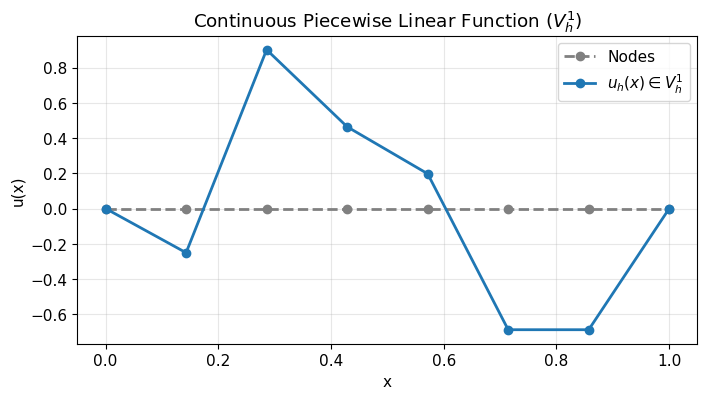

In [13]:
# Visualizing a piecewise linear function in V_h^1
np.random.seed(42)
npoints = 8
x_mesh = np.linspace(0, 1, num=npoints)
u_values = np.hstack([0, -1 + 2 * np.random.rand(npoints - 2), 0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_mesh, np.zeros(npoints), color='gray', linestyle='--', marker='o', label='Nodes')
ax.plot(x_mesh, u_values, 'o-', label=r'$u_h(x) \in V_h^1$')
ax.set_title('Continuous Piecewise Linear Function ($V_h^1$)')
ax.set_xlabel('x')
ax.set_ylabel('u(x)')
ax.grid(True)
ax.legend()
plt.show()

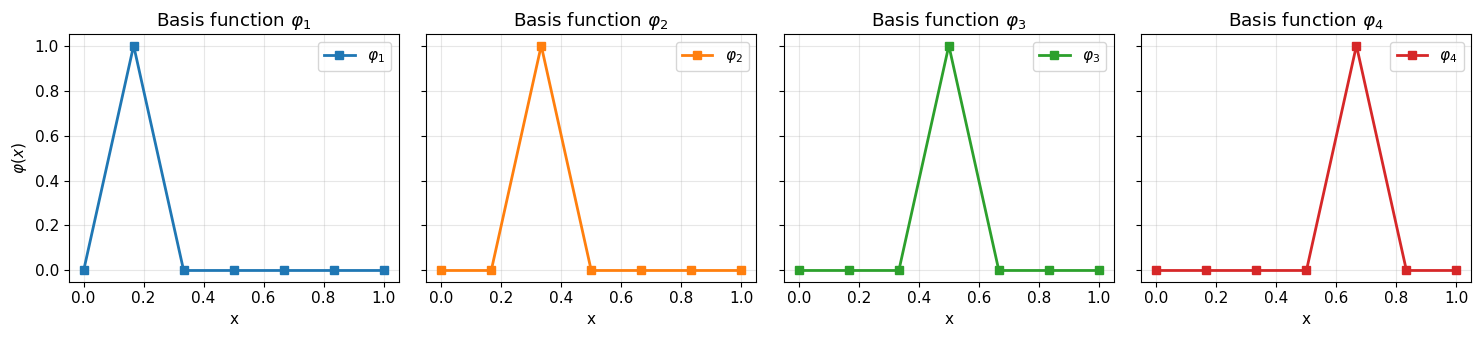

In [21]:
# Plotting the hat basis functions
n_sub = 6
x_hat = np.linspace(0, 1, n_sub + 1)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for idx, node_i in enumerate(range(1, 5)):
    phi_i = np.zeros(n_sub + 1)
    phi_i[node_i] = 1.0
    axes[idx].plot(x_hat, phi_i, color=f'C{idx}', marker='s', label=r'$\varphi$'+f'$_{{{node_i}}}$')
    axes[idx].set_title('Basis function '+r'$\varphi$'+f'$_{{{node_i}}}$')
    axes[idx].set_xlabel('x')
    axes[idx].grid(True)
    axes[idx].legend()
axes[0].set_ylabel(r'$\varphi(x)$')
plt.tight_layout()
plt.show();

### Analytical Stiffness Matrix for $\mathbb{P}^1$ Elements

For a uniform mesh of step size $h$, the derivatives of the hat functions are piecewise constant:

$$
\varphi_j'(x) = \begin{cases}
\frac{1}{h}, & x \in (x_{j-1}, x_j) \\[1ex]
-\frac{1}{h}, & x \in (x_j, x_{j+1}) \\[1ex]
0, & \text{otherwise}
\end{cases}
$$

Evaluating $A_{ij} = a(\varphi_j, \varphi_i) = \int_a^b \varphi_j'(x) \varphi_i'(x) \, dx$ yields:

$$
a(\varphi_j, \varphi_i) = \begin{cases}
\frac{2}{h}, & \text{if } i = j \\[1ex]
-\frac{1}{h}, & \text{if } |i - j| = 1 \\[1ex]
0, & \text{otherwise}
\end{cases}
$$

Thus, the global stiffness matrix $A$ for interior nodes is tridiagonal and symmetric positive definite.

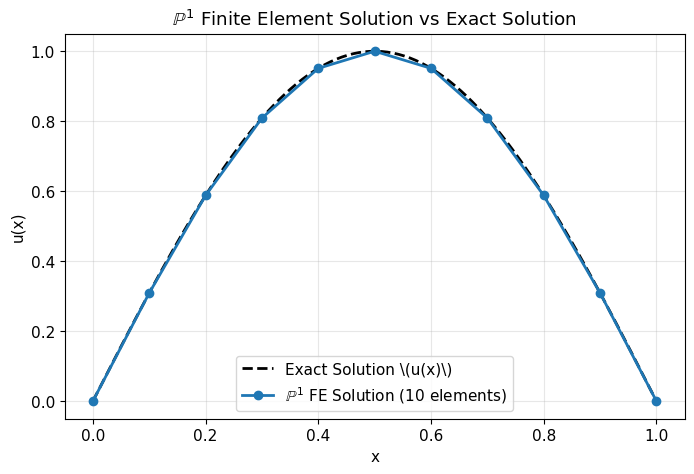

In [23]:
def solve_poisson_p1_uniform(f_func, n_intervals):
    """Solves -u'' = f on (0,1) with u(0)=u(1)=0 using linear FE on a uniform grid."""
    h = 1.0 / n_intervals
    x = np.linspace(0, 1, n_intervals + 1)
    
    # Interior nodes count
    N = n_intervals - 1
    
    # Assembly of stiffness matrix A
    main_diag = (2.0 / h) * np.ones(N)
    off_diag = (-1.0 / h) * np.ones(N - 1)
    A = sps.diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csr')
    
    # Assembly of load vector b using Simpson's rule or numerical quadrature
    b = np.zeros(N)
    for i in range(N):
        xi = x[i + 1]
        # Integral over (x_{i-1}, x_i)
        val1, _ = quadrature(lambda t: f_func(t) * (t - x[i]) / h, x[i], xi)
        # Integral over (x_i, x_{i+1})
        val2, _ = quadrature(lambda t: f_func(t) * (x[i + 2] - t) / h, xi, x[i + 2])
        b[i] = val1 + val2
        
    # Solve linear system
    u_interior = spsolve(A, b)
    
    # Construct full solution including boundaries
    u_full = np.zeros(n_intervals + 1)
    u_full[1:-1] = u_interior
    
    return x, u_full

# Test implementation with f(x) = pi^2 * sin(pi * x), exact solution u(x) = sin(pi * x)
f_test = lambda x: np.pi**2 * np.sin(np.pi * x)
u_exact = lambda x: np.sin(np.pi * x)

x_p1, u_p1 = solve_poisson_p1_uniform(f_test, n_intervals=10)

plt.figure(figsize=(8, 5))
x_fine = np.linspace(0, 1, 200)
plt.plot(x_fine, u_exact(x_fine), 'k--', label='Exact Solution \(u(x)\)')
plt.plot(x_p1, u_p1, 'o-', color='C0', label=r'$\mathbb{P}^1$ FE Solution (10 elements)')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title(r'$\mathbb{P}^1$ Finite Element Solution vs Exact Solution')
plt.grid(True)
plt.legend()
plt.show()

## 3. Higher-Order Finite Elements ($\mathbb{P}^p$) using Bernstein Polynomials

To achieve higher accuracy, we consider polynomial approximations of degree $p \ge 1$ within each element.

### Bernstein Basis Functions
The Bernstein basis polynomials of degree $p$ on the reference interval $[0, 1]$ are defined by:

$$
B_j^p(x) = \binom{p}{j} (1-x)^{p-j} x^j, \quad j = 0, \dots, p
$$

For an arbitrary interval $I = (a, b)$, we define local barycentric coordinates:

$$
\lambda_1(x) = \frac{b - x}{b - a}, \qquad \lambda_2(x) = \frac{x - a}{b - a}
$$

The Bernstein basis polynomials on $I$ are given by:

$$
B_j^p(x) = \binom{p}{j} \lambda_1(x)^{p-j} \lambda_2(x)^j, \quad j = 0, \dots, p
$$

#### Derivative Property
A key algebraic advantage of Bernstein polynomials is that their derivative can be expressed concisely in terms of lower-degree Bernstein polynomials:

$$
\frac{d}{dx} B_j^p(x) = \frac{p}{b - a} \left( B_{j-1}^{p-1}(x) - B_j^{p-1}(x) \right)
$$

where $B_{-1}^{p-1}(x) = 0$ and $B_p^{p-1}(x) = 0$ by convention.

In [5]:
def bernstein_poly(x, j, p, I=(0, 1)):
    """Evaluates the j-th Bernstein polynomial of degree p on interval I=[a, b]."""
    if 0 <= j <= p:
        a, b = I[0], I[1]
        l1 = (b - x) / (b - a)
        l2 = (x - a) / (b - a)
        return comb(p, j) * (l1**(p - j)) * (l2**j)
    else:
        return np.zeros_like(x) if isinstance(x, np.ndarray) else 0.0

def dbernstein_poly(x, j, p, I=(0, 1)):
    """Evaluates derivative of j-th Bernstein polynomial of degree p on interval I=[a, b]."""
    if 0 <= j <= p:
        a, b = I[0], I[1]
        term1 = bernstein_poly(x, j - 1, p - 1, I)
        term2 = bernstein_poly(x, j, p - 1, I)
        return p * (term1 - term2) / (b - a)
    else:
        return np.zeros_like(x) if isinstance(x, np.ndarray) else 0.0

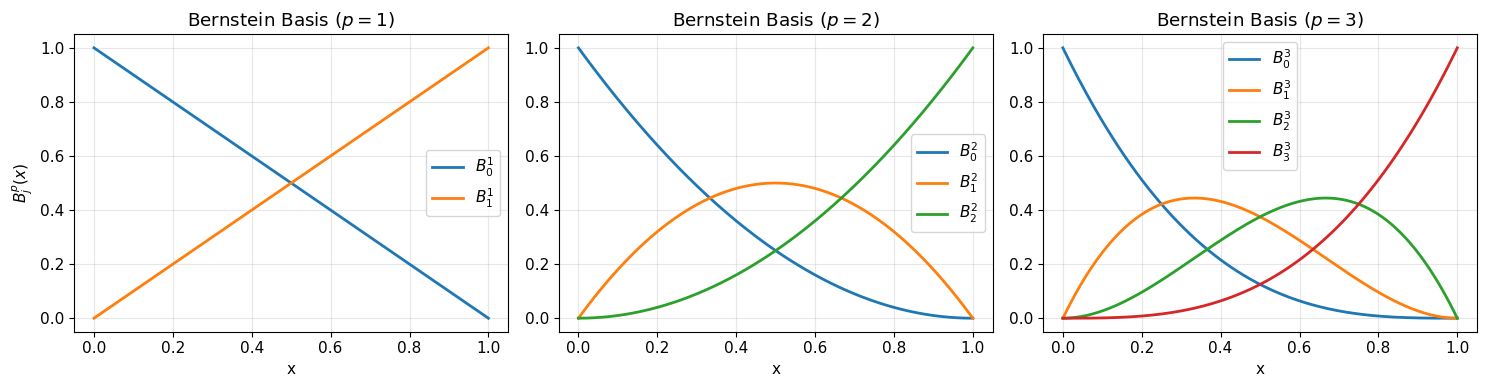

In [26]:
# Plotting Bernstein basis polynomials for degrees p=1, 2, 3
x_vals = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, p in enumerate([1, 2, 3]):
    for j in range(p + 1):
        y_vals = bernstein_poly(x_vals, j, p)
        axes[idx].plot(x_vals, y_vals, label=f'$B_{{{j}}}^{{{p}}}$')
    axes[idx].set_title(f'Bernstein Basis ($p={p}$)')
    axes[idx].set_xlabel('x')
    axes[idx].grid(True)
    axes[idx].legend()

axes[0].set_ylabel('$B_j^p(x)$')
plt.tight_layout()
plt.show()

### Higher-Order Matrix Assembly Scheme

To construct $V_h^p$, we assign $p+1$ degrees of freedom per element. Nodes at element boundaries are shared to ensure $C^0$-continuity across subinterval boundaries.

The assembling algorithm forms element stiffness matrices $A^e \in \mathbb{R}^{(p+1) \times (p+1)}$ and element load vectors $b^e \in \mathbb{R}^{p+1}$:

$$
A^e_{ij} = \int_{K_e} \frac{d B_j^p}{dx} \frac{d B_i^p}{dx} \, dx, \qquad b^e_i = \int_{K_e} f(x) B_i^p(x) \, dx
$$

These local contributions are mapped into a global linear system $A_{global} c = b_{global}$ using local-to-global indexing.

In [7]:
def solve_poisson_higher_order(f_func, n_intervals, degree=2, domain=(0, 1)):
    """Solves -u'' = f on domain with u(a)=u(b)=0 using higher-order Bernstein FE."""
    a, b = domain
    nodes = np.linspace(a, b, n_intervals + 1)
    p = degree
    
    # Total degrees of freedom across the domain
    num_dofs = n_intervals * p + 1
    
    A_global = np.zeros((num_dofs, num_dofs))
    b_global = np.zeros(num_dofs)
    
    # Assembly loop over elements
    for e in range(n_intervals):
        I_e = (nodes[e], nodes[e+1])
        dof_indices = [e * p + j for j in range(p + 1)]
        
        # Local element matrix and vector assembly
        A_elem = np.zeros((p + 1, p + 1))
        b_elem = np.zeros(p + 1)
        
        for i in range(p + 1):
            # Compute element load vector b_elem[i]
            integrand_b = lambda x: f_func(x) * bernstein_poly(x, i, p, I_e)
            b_elem[i], _ = quadrature(integrand_b, I_e[0], I_e[1], maxiter=100)
            
            for j in range(p + 1):
                # Compute element stiffness matrix A_elem[i, j]
                integrand_A = lambda x: dbernstein_poly(x, i, p, I_e) * dbernstein_poly(x, j, p, I_e)
                A_elem[i, j], _ = quadrature(integrand_A, I_e[0], I_e[1], maxiter=100)
        
        # Global matrix scatter/assembly
        for i in range(p + 1):
            b_global[dof_indices[i]] += b_elem[i]
            for j in range(p + 1):
                A_global[dof_indices[i], dof_indices[j]] += A_elem[i, j]
                
    # Enforce Homogeneous Dirichlet BCs (u(a) = 0, u(b) = 0)
    free_dofs = list(range(1, num_dofs - 1))
    
    A_free = A_global[np.ix_(free_dofs, free_dofs)]
    b_free = b_global[free_dofs]
    
    # Solve for interior degrees of freedom
    c_free = np.linalg.solve(A_free, b_free)
    
    c_full = np.zeros(num_dofs)
    c_full[free_dofs] = c_free
    
    return nodes, c_full, degree

def evaluate_solution(x_eval, nodes, c_full, degree):
    """Evaluates the FE solution at arbitrary visualization points x_eval."""
    p = degree
    n_intervals = len(nodes) - 1
    u_eval = np.zeros_like(x_eval)
    
    for idx, x in enumerate(x_eval):
        # Locate element
        for e in range(n_intervals):
            if nodes[e] <= x <= nodes[e+1] or (e == n_intervals - 1 and x >= nodes[e+1]):
                I_e = (nodes[e], nodes[e+1])
                dof_indices = [e * p + j for j in range(p + 1)]
                val = sum(c_full[dof_indices[j]] * bernstein_poly(x, j, p, I_e) for j in range(p + 1))
                u_eval[idx] = val
                break
    return u_eval

## 4. Extension: Non-Homogeneous Dirichlet Boundary Conditions

Consider the general Dirichlet boundary value problem:

$$
-u''(x) = f(x) \quad \text{in } (a, b), \qquad u(a) = u_a, \quad u(b) = u_b
$$

To handle non-homogeneous boundary conditions, we express the solution as:

$$
u(x) = u_0(x) + u_D(x)
$$

where $u_D(x)$ is an extension function satisfying the boundary conditions $u_D(a) = u_a$ and $u_D(b) = u_b$, and $u_0 \in H_0^1(\Omega)$ satisfies zero boundary conditions. A standard linear extension is:

$$
u_D(x) = u_a \frac{b - x}{b - a} + u_b \frac{x - a}{b - a}
$$

Substituting $u = u_0 + u_D$ into the bilinear form yields:

$$
a(u_0, v) = L(v) - a(u_D, v) \quad \forall v \in H_0^1(\Omega)
$$

In matrix form, the Dirichlet values are directly assigned to boundary DoFs ($c_0 = u_a, c_{N} = u_b$), and the system is solved for the interior DoFs after modifying the right-hand side vector $b$.

In [8]:
def solve_poisson_general_dirichlet(f_func, u_a, u_b, n_intervals, degree=2, domain=(0, 1)):
    """Solves -u'' = f on domain with u(a) = u_a and u(b) = u_b."""
    a, b = domain
    nodes = np.linspace(a, b, n_intervals + 1)
    p = degree
    num_dofs = n_intervals * p + 1
    
    A_global = np.zeros((num_dofs, num_dofs))
    b_global = np.zeros(num_dofs)
    
    for e in range(n_intervals):
        I_e = (nodes[e], nodes[e+1])
        dof_indices = [e * p + j for j in range(p + 1)]
        
        A_elem = np.zeros((p + 1, p + 1))
        b_elem = np.zeros(p + 1)
        
        for i in range(p + 1):
            integrand_b = lambda x: f_func(x) * bernstein_poly(x, i, p, I_e)
            b_elem[i], _ = quadrature(integrand_b, I_e[0], I_e[1], maxiter=100)
            
            for j in range(p + 1):
                integrand_A = lambda x: dbernstein_poly(x, i, p, I_e) * dbernstein_poly(x, j, p, I_e)
                A_elem[i, j], _ = quadrature(integrand_A, I_e[0], I_e[1], maxiter=100)
        
        for i in range(p + 1):
            b_global[dof_indices[i]] += b_elem[i]
            for j in range(p + 1):
                A_global[dof_indices[i], dof_indices[j]] += A_elem[i, j]
                
    # Set boundary coefficients directly
    c_full = np.zeros(num_dofs)
    c_full[0] = u_a
    c_full[-1] = u_b
    
    free_dofs = list(range(1, num_dofs - 1))
    boundary_dofs = [0, num_dofs - 1]
    
    # Modify RHS for non-homogeneous Dirichlet boundary conditions
    b_free = b_global[free_dofs] - A_global[np.ix_(free_dofs, boundary_dofs)] @ c_full[boundary_dofs]
    A_free = A_global[np.ix_(free_dofs, free_dofs)]
    
    c_full[free_dofs] = np.linalg.solve(A_free, b_free)
    
    return nodes, c_full, degree

## 5. Numerical Experiments and Convergence Analysis

### Test Problem
We validate the implementation against the analytical benchmark:

$$
-u''(x) = \pi^2 \sin(\pi x) \quad \text{in } (0,1), \qquad u(0) = 0, \quad u(1) = 0
$$

with exact solution $u_{exact}(x) = \sin(\pi x)$.

We compare polynomial approximations of degrees $p = 1, 2, 3$ and measure the $L^2$ error norm defined by:

$$
\|u - u_h\|_{L^2(\Omega)} = \left( \int_{a}^{b} |u(x) - u_h(x)|^2 \, dx \right)^{1/2}
$$

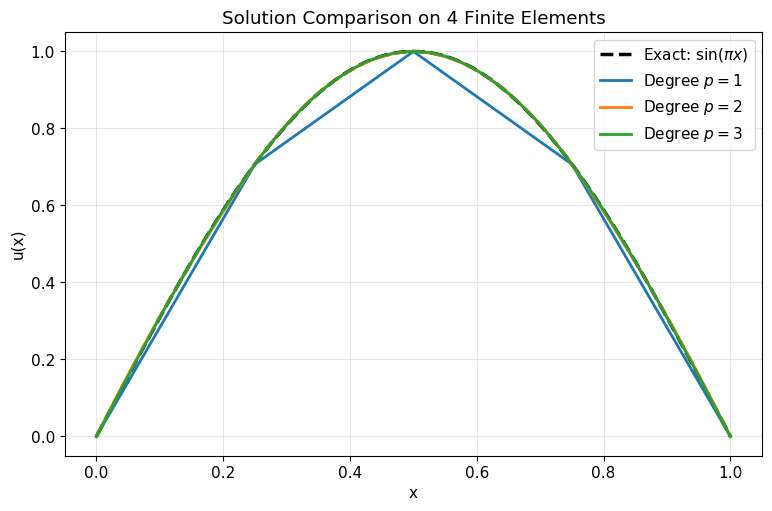

In [32]:
# Benchmark Setup
f_bench = lambda x: np.pi**2 * np.sin(np.pi * x)
u_bench = lambda x: np.sin(np.pi * x)
u_bench_prime = lambda x: np.pi*np.cos(np.pi * x)

n_elem = 4
x_plot = np.linspace(0, 1, 300)
u_true = u_bench(x_plot)

plt.figure(figsize=(9, 5.5))
plt.plot(x_plot, u_true, 'k--', label='Exact: $\sin(\pi x)$', linewidth=2.5)

for p_deg in [1, 2, 3]:
    nodes, c_sol, deg = solve_poisson_higher_order(f_bench, n_elem, degree=p_deg)
    u_approx = evaluate_solution(x_plot, nodes, c_sol, deg)
    plt.plot(x_plot, u_approx, label=f'Degree $p={p_deg}$')

plt.title(f'Solution Comparison on {n_elem} Finite Elements')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid(True)
plt.legend()
plt.show()

### $L^2$ Error Convergence Rates

Finite element theory predicts that for smooth solutions, the $L^2$ error behaves as $\mathcal{O}(h^{p+1})$, where $h$ is the maximum mesh element size and $p$ is the polynomial degree.

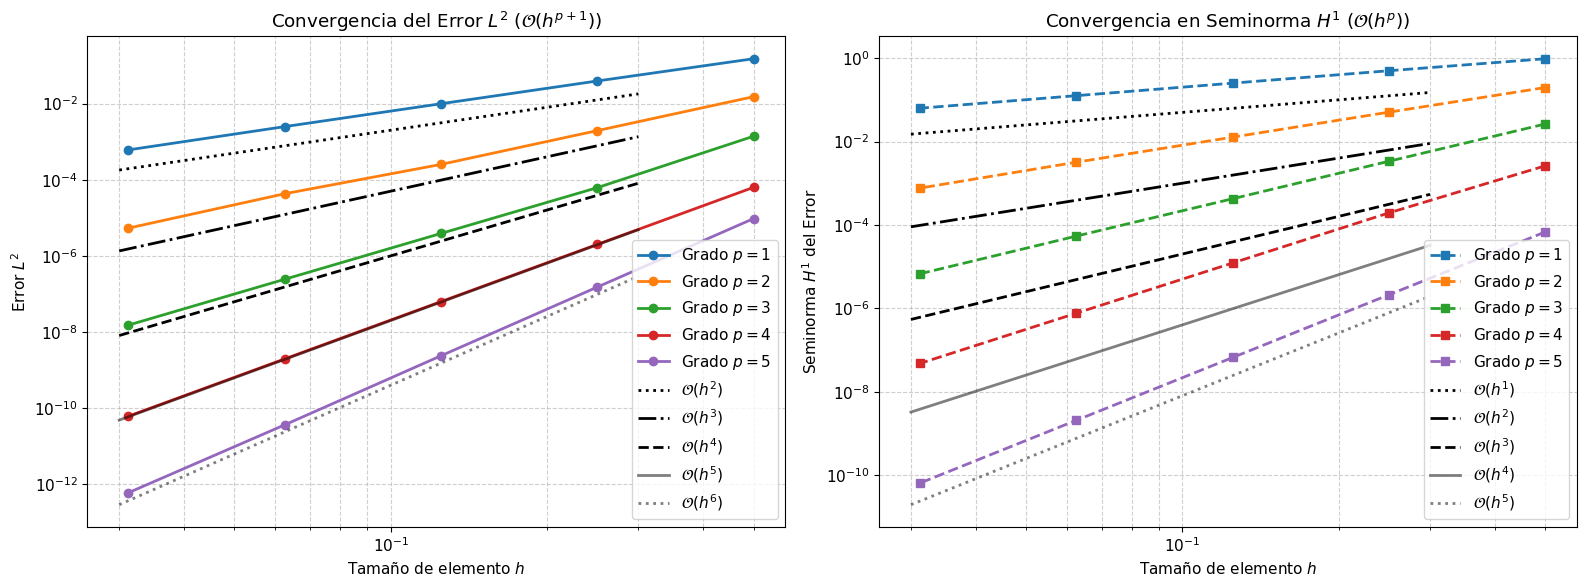


=== TABLA DE ERROR L2 ===
h       p=1 Error      p=2 Error      p=3 Error      p=4 Error      p=5 Error      
-----------------------------------------------------------------------------------
0.5000  1.5088e-01     1.5186e-02     1.3881e-03     6.3093e-05     9.5395e-06     
0.2500  3.9284e-02     1.9518e-03     6.1934e-05     2.0058e-06     1.5160e-07     
0.1250  9.9209e-03     2.5291e-04     3.8872e-06     6.2949e-08     2.3775e-09     
0.0625  2.4860e-03     4.2895e-05     2.4320e-07     1.9693e-09     3.6498e-11     
0.0312  6.0894e-04     5.3644e-06     1.5204e-08     6.1557e-11     6.0225e-13     

=== TABLA DE ERROR EN SEMINORMA H1 ===
h       p=1 Error      p=2 Error      p=3 Error      p=4 Error      p=5 Error      
-----------------------------------------------------------------------------------
0.5000  9.6685e-01     1.9719e-01     2.6332e-02     2.6172e-03     6.7848e-05     
0.2500  4.9851e-01     5.0620e-02     3.3650e-03     1.9448e-04     2.1146e-06     
0.1250  2

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quadrature
from scipy.special import comb

def bernstein_poly(x, i, p, interval):
    """Evalúa el i-ésimo polinomio de Bernstein de grado p en x dentro del intervalo."""
    a, b = interval
    t = (x - a) / (b - a)
    return comb(p, i) * (t**i) * ((1 - t)**(p - i))

def bernstein_poly_deriv(x, i, p, interval):
    """Calcula d/dx del i-ésimo polinomio de Bernstein de grado p."""
    a, b = interval
    h_e = b - a
    if p == 0:
        return 0.0 if np.isscalar(x) else np.zeros_like(x)
    
    t = (x - a) / h_e
    term1 = comb(p - 1, i - 1) * (t**(i - 1)) * ((1 - t)**(p - i)) if i > 0 else 0.0
    term2 = comb(p - 1, i) * (t**i) * ((1 - t)**(p - 1 - i)) if i < p else 0.0
    
    return (p / h_e) * (term1 - term2)

def compute_errors(f_func, u_exact, u_exact_prime, n_elem, degree):
    """Calcula los errores en la norma L2 y en la seminorma H1 utilizando cuadratura de Gauss."""
    nodes, c_sol, deg = solve_poisson_higher_order(f_func, n_elem, degree)
    p = degree
    
    total_sq_l2_error = 0.0
    total_sq_h1_error = 0.0
    
    for e in range(n_elem):
        I_e = (nodes[e], nodes[e+1])
        dof_indices = [e * p + j for j in range(p + 1)]
        
        # Integrando L2: (u(x) - u_h(x))^2
        l2_integrand = lambda x: (
            u_exact(x) - sum(c_sol[dof_indices[j]] * bernstein_poly(x, j, p, I_e) for j in range(p + 1))
        )**2
        
        # Integrando H1: (u'(x) - u_h'(x))^2
        h1_integrand = lambda x: (
            u_exact_prime(x) - sum(c_sol[dof_indices[j]] * bernstein_poly_deriv(x, j, p, I_e) for j in range(p + 1))
        )**2
        
        sq_err_l2, _ = quadrature(l2_integrand, I_e[0], I_e[1], maxiter=200)
        sq_err_h1, _ = quadrature(h1_integrand, I_e[0], I_e[1], maxiter=200)
        
        total_sq_l2_error += sq_err_l2
        total_sq_h1_error += sq_err_h1
        
    return np.sqrt(total_sq_l2_error), np.sqrt(total_sq_h1_error)

# ==============================================================================
# PRUEBA DE CONVERGENCIA POR REFINAMIENTO DE MALLA (p = 1 a 5)
# ==============================================================================

element_counts = [2, 4, 8, 16, 32]
degrees = [1, 2, 3, 4, 5]

l2_errors = {p: [] for p in degrees}
h1_errors = {p: [] for p in degrees}

for p in degrees:
    for n in element_counts:
        err_l2, err_h1 = compute_errors(f_bench, u_bench, u_bench_prime, n, p)
        l2_errors[p].append(err_l2)
        h1_errors[p].append(err_h1)

# ==============================================================================
# GRÁFICOS DE CONVERGENCIA (L2 y H1)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
h_sizes = [1.0 / n for n in element_counts]
h_ref = np.array([0.03, 0.3])

# --- Gráfico 1: Error L2 ---
for p in degrees:
    axes[0].loglog(h_sizes, l2_errors[p], 'o-', label=f'Grado $p={p}$')

# Líneas de referencia para L2 (O(h^(p+1)))
axes[0].loglog(h_ref, 0.2 * h_ref**2, 'k:', label=r'$\mathcal{O}(h^2)$')
axes[0].loglog(h_ref, 0.05 * h_ref**3, 'k-.', label=r'$\mathcal{O}(h^3)$')
axes[0].loglog(h_ref, 0.01 * h_ref**4, 'k--', label=r'$\mathcal{O}(h^4)$')
axes[0].loglog(h_ref, 0.002 * h_ref**5, 'k-', alpha=0.5, label=r'$\mathcal{O}(h^5)$')
axes[0].loglog(h_ref, 0.0004 * h_ref**6, 'k:', alpha=0.5, label=r'$\mathcal{O}(h^6)$')

axes[0].set_xlabel(r'Tamaño de elemento $h$')
axes[0].set_ylabel(r'Error $L^2$')
axes[0].set_title(r'Convergencia del Error $L^2$ ($\mathcal{O}(h^{p+1})$)')
axes[0].grid(True, which='both', linestyle='--', alpha=0.6)
axes[0].legend()

# --- Gráfico 2: Seminorma H1 ---
for p in degrees:
    axes[1].loglog(h_sizes, h1_errors[p], 's--', label=f'Grado $p={p}$')

# Líneas de referencia para H1 (O(h^p))
axes[1].loglog(h_ref, 0.5 * h_ref**1, 'k:', label=r'$\mathcal{O}(h^1)$')
axes[1].loglog(h_ref, 0.1 * h_ref**2, 'k-.', label=r'$\mathcal{O}(h^2)$')
axes[1].loglog(h_ref, 0.02 * h_ref**3, 'k--', label=r'$\mathcal{O}(h^3)$')
axes[1].loglog(h_ref, 0.004 * h_ref**4, 'k-', alpha=0.5, label=r'$\mathcal{O}(h^4)$')
axes[1].loglog(h_ref, 0.0008 * h_ref**5, 'k:', alpha=0.5, label=r'$\mathcal{O}(h^5)$')

axes[1].set_xlabel(r'Tamaño de elemento $h$')
axes[1].set_ylabel(r'Seminorma $H^1$ del Error')
axes[1].set_title(r'Convergencia en Seminorma $H^1$ ($\mathcal{O}(h^p)$)')
axes[1].grid(True, which='both', linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==============================================================================
# TABLAS DE CONVERGENCIA
# ==============================================================================

print("\n=== TABLA DE ERROR L2 ===")
header_l2 = f"{'h':<8}" + "".join([f"{'p=' + str(p) + ' Error':<15}" for p in degrees])
print(header_l2)
print("-" * len(header_l2))
for idx, n in enumerate(element_counts):
    h = 1.0 / n
    row = f"{h:<8.4f}" + "".join([f"{l2_errors[p][idx]:<15.4e}" for p in degrees])
    print(row)

print("\n=== TABLA DE ERROR EN SEMINORMA H1 ===")
header_h1 = f"{'h':<8}" + "".join([f"{'p=' + str(p) + ' Error':<15}" for p in degrees])
print(header_h1)
print("-" * len(header_h1))
for idx, n in enumerate(element_counts):
    h = 1.0 / n
    row = f"{h:<8.4f}" + "".join([f"{h1_errors[p][idx]:<15.4e}" for p in degrees])
    print(row)

In [47]:
import pandas as pd

# Diccionario para almacenar el DataFrame de cada subespacio
dfs_convergencia = {}

h_sizes = [1.0 / n for n in element_counts]

for p in degrees:
    data = []
    for idx, n in enumerate(element_counts):
        h = h_sizes[idx]
        err_l2 = l2_errors[p][idx]
        err_h1 = h1_errors[p][idx]
        
        if idx == 0:
            eoc_l2 = np.nan
            eoc_h1 = np.nan
        else:
            eoc_l2 = np.log(l2_errors[p][idx-1] / err_l2) / np.log(h_sizes[idx-1] / h)
            eoc_h1 = np.log(h1_errors[p][idx-1] / err_h1) / np.log(h_sizes[idx-1] / h)
            
        data.append({
            'h': h,
            'Error L2': err_l2,
            'EOC L2': eoc_l2,
            'Error H1': err_h1,
            'EOC H1': eoc_h1
        })
    
    df = pd.DataFrame(data)
    dfs_convergencia[p] = df

# ==============================================================================
# IMPRESIÓN FORMATO TABLA DE PANDAS
# ==============================================================================

# Formato personalizado para mostrar notación científica en errores y decimales en EOC
pd.options.display.float_format = '{:.4e}'.format

for p in degrees:
    # print(f"\n================ Subespacio p = {p} ================")
    
    # Creamos una copia para formatear EOC sin alterar los valores numéricos reales
    df_display = dfs_convergencia[p].copy()
    df_display['EOC L2'] = df_display['EOC L2'].apply(lambda x: f"{x:.2f}" if pd.notnull(x) else "-")
    df_display['EOC H1'] = df_display['EOC H1'].apply(lambda x: f"{x:.2f}" if pd.notnull(x) else "-")
    # print(df_display.to_string(index=False))
# Requiere: pip install tabulate

    # Exportar la tabla de p=1 a código LaTeX
    # print(dfs_convergencia[1].to_latex(index=False, float_format="%.4e"))


### Subespacio p = 1

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 0.15088    | -        |   0.96685  | -        |
| 0.25   | 0.039284   | 1.94     |   0.49851  | 0.96     |
| 0.125  | 0.0099209  | 1.99     |   0.25118  | 0.99     |
| 0.0625 | 0.002486   | 2.00     |   0.12583  | 1.00     |
| 0.0312 | 0.00060894 | 2.03     |   0.062947 | 1.00     |

### Subespacio p = 2

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 0.015186   | -        | 0.19719    | -        |
| 0.25   | 0.0019518  | 2.96     | 0.05062    | 1.96     |
| 0.125  | 0.00025291 | 2.95     | 0.012739   | 1.99     |
| 0.0625 | 4.2895e-05 | 2.56     | 0.0031899  | 2.00     |
| 0.0312 | 5.3644e-06 | 3.00     | 0.00076507 | 2.06     |

### Subespacio p = 3

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------

### Subespacio p = 1

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 0.15088    | -        |   0.96685  | -        |
| 0.25   | 0.039284   | 1.94     |   0.49851  | 0.96     |
| 0.125  | 0.0099209  | 1.99     |   0.25118  | 0.99     |
| 0.0625 | 0.002486   | 2.00     |   0.12583  | 1.00     |
| 0.0312 | 0.00060894 | 2.03     |   0.062947 | 1.00     |

### Subespacio p = 2

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 0.015186   | -        | 0.19719    | -        |
| 0.25   | 0.0019518  | 2.96     | 0.05062    | 1.96     |
| 0.125  | 0.00025291 | 2.95     | 0.012739   | 1.99     |
| 0.0625 | 4.2895e-05 | 2.56     | 0.0031899  | 2.00     |
| 0.0312 | 5.3644e-06 | 3.00     | 0.00076507 | 2.06     |

### Subespacio p = 3

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 0.0013881  | -        | 0.026332   | -        |
| 0.25   | 6.1934e-05 | 4.49     | 0.003365   | 2.97     |
| 0.125  | 3.8872e-06 | 3.99     | 0.00042433 | 2.99     |
| 0.0625 | 2.432e-07  | 4.00     | 5.3912e-05 | 2.98     |
| 0.0312 | 1.5204e-08 | 4.00     | 6.7414e-06 | 3.00     |

### Subespacio p = 4

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 6.3093e-05 | -        | 0.0026172  | -        |
| 0.25   | 2.0058e-06 | 4.98     | 0.00019448 | 3.75     |
| 0.125  | 6.2949e-08 | 4.99     | 1.221e-05  | 3.99     |
| 0.0625 | 1.9693e-09 | 5.00     | 7.6402e-07 | 4.00     |
| 0.0312 | 6.1557e-11 | 5.00     | 4.7765e-08 | 4.00     |

### Subespacio p = 5

|      h |   Error L2 | EOC L2   |   Error H1 | EOC H1   |
|--------|------------|----------|------------|----------|
| 0.5    | 9.5395e-06 | -        | 6.7848e-05 | -        |
| 0.25   | 1.516e-07  | 5.98     | 2.1146e-06 | 5.00     |
| 0.125  | 2.3775e-09 | 5.99     | 6.6032e-08 | 5.00     |
| 0.0625 | 3.6498e-11 | 6.03     | 2.0627e-09 | 5.00     |
| 0.0312 | 6.0225e-13 | 5.92     | 6.4486e-11 | 5.00     |

### Non-Homogeneous Dirichlet Test

Finally, we verify the implementation on a non-homogeneous Dirichlet boundary value problem:

$$
-u''(x) = -2 \quad \text{in } (0,2), \qquad u(0) = 1, \quad u(2) = 3
$$

The analytical solution is quadratic: $u(x) = x^2 + 1$.

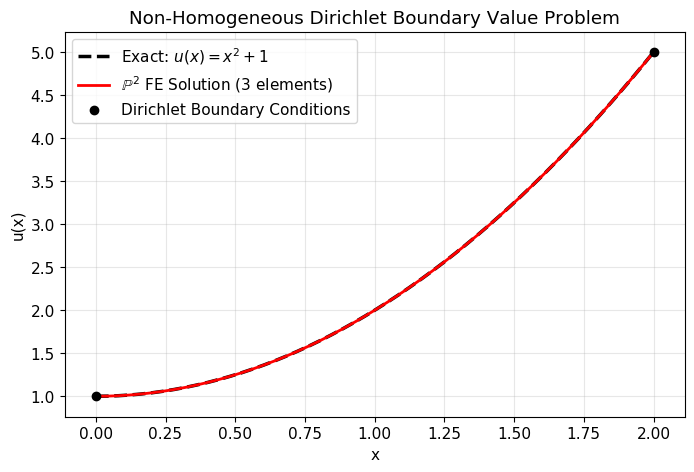

In [30]:
# General Dirichlet Example Setup
f_dir = lambda x: -2.0 * np.ones_like(x) if isinstance(x, np.ndarray) else -2.0
u_dir_exact = lambda x: x**2 + 1.0

nodes_d, c_sol_d, deg_d = solve_poisson_general_dirichlet(
    f_dir, u_a=1.0, u_b=5.0, n_intervals=3, degree=2, domain=(0, 2)
)

x_test_dir = np.linspace(0, 2, 200)
u_dir_fem = evaluate_solution(x_test_dir, nodes_d, c_sol_d, deg_d)

plt.figure(figsize=(8, 5))
plt.plot(x_test_dir, u_dir_exact(x_test_dir), 'k--', label='Exact: $u(x) = x^2 + 1$', linewidth=2.5)
plt.plot(x_test_dir, u_dir_fem, 'r-', label='$\mathbb{P}^2$ FE Solution (3 elements)')
plt.scatter([0, 2], [1.0, 5.0], color='black', zorder=5, label='Dirichlet Boundary Conditions')
plt.title('Non-Homogeneous Dirichlet Boundary Value Problem')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid(True)
plt.legend()
plt.show()

### Static Condensation in High-Order Finite Element Methods

In high-order Finite Element Methods (FEM), expanding polynomial spaces up to degree $p$ drastically increases the total number of Degrees of Freedom (DOFs). Standard global assembly leads to large system matrices, elevating memory consumption and computational cost.

**Static Condensation** addresses this by partitioning the local elemental DOFs into two distinct groups:

1. **Boundary DOFs ($\mathbf{u}_{\partial}$):** DOFs shared between adjacent elements (e.g., cell vertices or faces).
2. **Interior DOFs ($\mathbf{u}_0$):** High-order bubble DOFs whose support is entirely contained within a single element $K$.

Because interior shape functions are completely decoupled across element boundaries, the local linear system for an element $K$ can be written in block form:

$$\begin{bmatrix}  \mathbf{A}_{00} & \mathbf{A}_{0\partial} \\  \mathbf{A}_{\partial 0} & \mathbf{A}_{\partial\partial}  \end{bmatrix}  \begin{bmatrix}  \mathbf{u}_0 \\ \mathbf{u}_{\partial}  \end{bmatrix}  =  \begin{bmatrix}  \mathbf{b}_0 \\ \mathbf{b}_{\partial}  \end{bmatrix}$$

Since $\mathbf{A}_{00}$ corresponds strictly to local interior interactions, it is non-singular and easily invertible at the element level. Solving for the interior DOFs yields:

$$\mathbf{u}_0 = \mathbf{A}_{00}^{-1} \left( \mathbf{b}_0 - \mathbf{A}_{0\partial} \mathbf{u}_{\partial} \right)$$

Substituting $\mathbf{u}_0$ back into the second equation eliminates the interior unknowns prior to global assembly, resulting in the reduced **Schur Complement System**:

$$\mathbf{S}_K \mathbf{u}_{\partial} = \mathbf{b}_K^*$$

where:

* **Condensed Local Stiffness Matrix:** $\mathbf{S}_K = \mathbf{A}_{\partial\partial} - \mathbf{A}_{\partial 0} \mathbf{A}_{00}^{-1} \mathbf{A}_{0\partial}$
* **Condensed Local Load Vector:** $\mathbf{b}_K^* = \mathbf{b}_{\partial} - \mathbf{A}_{\partial 0} \mathbf{A}_{00}^{-1} \mathbf{b}_0$

#### Primary Advantages

* **Reduced Global Matrix Size:** For $p > 1$, global assembly operates exclusively on boundary DOFs (a system of size $N_N \times N_N$), completely bypassing the interior DOFs during global factorization.
* **Efficient Local Reconstruction:** Once the global boundary solution $\mathbf{u}_{\partial}$ is computed, interior coefficients $\mathbf{u}_0$ can be efficiently recovered locally in parallel via element-wise back-substitution.

--

In [49]:

import numpy as np
import scipy.sparse as sps
import scipy.sparse.linalg as sps_linalg

def gauss_legendre_quadrature(p):
    """Retorna nodos y pesos de Gauss-Legendre de orden suficiente para grado p."""
    n_points = max(p + 1, 2)
    nodes, weights = np.polynomial.legendre.leggauss(n_points)
    return nodes, weights

def fem1d_solver_static_condensation(Coordinates, Elements, f, p=1, return_full_dofs=False):
    """
    1D High-Order FEM Solver with Static Condensation using Bernstein basis.
    
    Parameters:
    Coordinates : ndarray
        1D array containing node coordinates.
    Elements : ndarray
        2D array of shape (NE, 2) defining element connectivity.
    f : callable
        RHS source term function f(x).
    p : int
        Polynomial degree per element.
    return_full_dofs : bool
        If True, reconstructs and returns interior DOFs along with nodal values.
    """
    NN = Coordinates.size
    NE = Elements.shape[0]
    
    # Cuadratura de Gauss-Legendre en [-1, 1]
    quad_nodes, quad_weights = gauss_legendre_quadrature(p)
    
    iS, jS, kS = [], [], []
    bs = np.zeros(NN, dtype=np.float64)
    
    # Almacenamiento local para la reconstrucción posterior de DOFs interiores
    interior_data = [] if (p > 1 and return_full_dofs) else None
    
    for j in range(NE):
        dofn = Elements[j, :]
        K = Coordinates[dofn]
        h_e = K[1] - K[0]
        
        # Mapeo afín desde [-1, 1] al elemento K = [a, b]
        x_q = a_q = K[0] + 0.5 * h_e * (quad_nodes + 1.0)
        
        # Evaluar bases y derivadas en los puntos de cuadratura
        # phi_q shape: (p+1, n_quad), dphi_q shape: (p+1, n_quad)
        phi_q = np.array([bernstein_poly(x_q, i, p, K) for i in range(p + 1)])
        dphi_q = np.array([bernstein_poly_deriv(x_q, i, p, K) for i in range(p + 1)])
        
        # Matriz de rigidez local AK e integración vectorizada
        # Integration weight: (h_e / 2) * w_q
        weight_factor = 0.5 * h_e * quad_weights
        AK = (dphi_q * weight_factor) @ dphi_q.T
        
        # Vector de carga local bK
        fx_q = f(x_q)
        bK = (phi_q * weight_factor) @ fx_q
        
        # --- Condensación Estática ---
        if p == 1:
            SK = AK
            bsK = bK
        else:
            # Partición: 0 -> interior (1:p), p -> frontera ([0, p])
            A00 = AK[1:p, 1:p]
            A0p = AK[1:p, [0, p]]
            Ap0 = AK[[0, p], 1:p]
            App = AK[[0, p], :][:, [0, p]]
            
            b0 = bK[1:p]
            bp = bK[[0, p]]
            
            # Matriz de transferencia G = (A00^-1 * A0p)^T
            G = np.linalg.solve(A00, A0p).T
            
            # Schur Complement local
            SK = App - G @ A0p
            bsK = bp - G @ b0
            
            if return_full_dofs:
                interior_data.append({'A00': A00, 'A0p': A0p, 'b0': b0, 'G': G})
        
        # Ensamblaje del vector de carga global reducido
        bs[dofn] += bsK
        
        # Ensamblaje en formato COO para la matriz reducida
        rows, cols = np.meshgrid(dofn, dofn, indexing='ij')
        iS.extend(rows.ravel())
        jS.extend(cols.ravel())
        kS.extend(SK.ravel())
    
    # Construcción de la matriz global globalmente reducida S (NN x NN)
    S = sps.coo_matrix((kS, (iS, jS)), shape=(NN, NN), dtype=np.float64).tocsc()
    
    # Aplicación de condiciones de contorno de Dirichlet homogéneas u(0) = u(1) = 0
    Free = np.arange(1, NN - 1)
    SFree = S[Free, :][:, Free]
    bsFree = bs[Free]
    
    # Resolver sistema lineal reducido
    uhnodes = np.zeros(NN, dtype=np.float64)
    uhnodes[Free] = sps_linalg.spsolve(SFree, bsFree)
    
    if not return_full_dofs or p == 1:
        return uhnodes
    
    # Reconstrucción local de DOFs interiores (u0 = A00^-1 * (b0 - A0p * u_boundary))
    u_full = np.zeros(NN + (p - 1) * NE, dtype=np.float64)
    u_full[:NN] = uhnodes
    
    for j in range(NE):
        dofn = Elements[j, :]
        u_boundary = uhnodes[dofn]
        data = interior_data[j]
        
        u0 = np.linalg.solve(data['A00'], data['b0'] - data['A0p'] @ u_boundary)
        
        # Mapeo de DOFs interiores al vector global
        interior_dofs = np.arange(NN + (p - 1) * j, NN + (p - 1) * (j + 1))
        u_full[interior_dofs] = u0
        
    return u_full

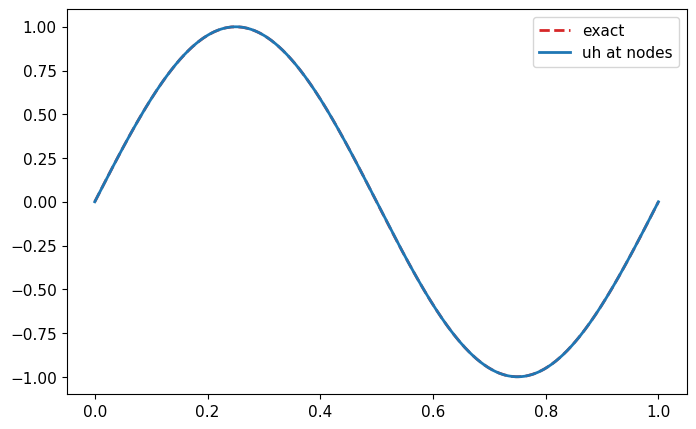

In [53]:

# Triangulation
def mesh(xi,xf,j):
    n = 2**j;
    Coordinates = np.linspace(xi,xf,num = n+2) # nodes 
    NN = Coordinates.size # number of coordinates or nodes
    Elements = np.vstack([range(n+1), range(1,n+2)]).T
    NE = Elements.shape[0] # number of elements
    h = np.max([abs(Coordinates[j+1] - Coordinates[j]) for j in range(n)]) # parameter of the triangulation
    return Coordinates, Elements, NN, NE, h
xi = 0; xf = 1;

u  = lambda x: np.sin(2*np.pi*x)
du = lambda x: 2*np.pi*np.cos(2*np.pi*x)
f  = lambda x: (2*np.pi)**2*np.sin(2*np.pi*x)
Coordinates, Elements, NN, _,_ = mesh(0,1,10)
uh = fem1d_solver_static_condensation(Coordinates, Elements, f, p=10)
x = np.linspace(0,1,100);
plt.plot(x, u(x), '--C3');
plt.plot(Coordinates,uh[range(NN)], 'C0'); 
plt.legend(['exact', 'uh at nodes'])
plt.show();

## Codigo Modularizado de FEM

Queremos resolver la siguiente ecuacion eliptica
$$
-\frac{d}{dx}\left( p(x) \frac{d}{dx}u(x)\right) + q(x)\frac{d}{dx}u(x)+ r(x)u(x) = f(x),\quad x\in (a,b)
$$
con condiciones de borde $u(a) = A, u(b) = B$.

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_jacobi

In [55]:
# Datos
class problem1delliptic:
    def __init__(self,a,b,f,A,B,p,q,r,dp,uexact=None,duexact=None,K0=None):
        self.a = a
        self.b = b
        self.f = f
        self.A = A
        self.B = B
        self.p = p
        self.dp = dp
        self.q = q
        self.r = r
        self.uexact = uexact
        self.duexact = duexact
        self.K0=K0

# problema ejemplo
a = 0.0; b= 1.0
f = lambda x: 2.0 +0*x
A = .0; B = .0
p = lambda x: 1.0+0*x
r = lambda x: 0+0*x
dp = lambda x: 0*x
q = lambda x: 0+0*x
uexact = lambda x: x*(1.0-x) 
problema1 = problem1delliptic(a,b,f,A,B,p,q,r,dp)

In [93]:
import numpy as np

class Triangulation1d:
    """Clase 1D para manejo de mallas y refinamiento adaptativo por bisección."""
    def __init__(self, Coordinates, Elements1d, Boundary=None):
        self.Coordinates = np.array(Coordinates, dtype=np.float64)
        self.Elements = np.array(Elements1d, dtype=np.int64)
        self.NN = self.Coordinates.size
        self.NE = self.Elements.shape[0]
        
        # Identificación geométrica infalible de la frontera (x_min y x_max)
        self.update_boundary()

    def update_boundary(self):
        """Actualiza los índices de frontera basándose en las coordenadas extremas del dominio."""
        min_idx = np.argmin(self.Coordinates)
        max_idx = np.argmax(self.Coordinates)
        self.Boundary = np.array([min_idx, max_idx], dtype=np.int64)

    def refinement(self, marked_elements):
        """Refina los elementos marcados e inmedia tamente actualiza fronteras."""
        marked_elements = np.unique(marked_elements)
        if marked_elements.size == 0:
            return

        old_NN = self.NN

        # Insertar puntos medios
        K_nodes = self.Coordinates[self.Elements[marked_elements]]
        new_coords = 0.5 * (K_nodes[:, 0] + K_nodes[:, 1])
        self.Coordinates = np.concatenate([self.Coordinates, new_coords])

        # Actualizar conectividad
        new_elements_list = []
        new_node_counter = old_NN

        for e_idx in range(self.NE):
            if e_idx in marked_elements:
                node_left = self.Elements[e_idx, 0]
                node_right = self.Elements[e_idx, 1]
                mid_node = new_node_counter
                
                new_elements_list.append([node_left, mid_node])
                new_elements_list.append([mid_node, node_right])
                new_node_counter += 1
            else:
                new_elements_list.append(self.Elements[e_idx])

        self.Elements = np.array(new_elements_list, dtype=np.int64)
        self.NN = self.Coordinates.size
        self.NE = self.Elements.shape[0]

        # Reordenar y actualizar frontera inmediatamente tras refinar
        self.sort_mesh()

    def sort_mesh(self):
        """Reordena nodos geométricamente (x_0 < x_1 < ... < x_N) y actualiza la frontera."""
        sort_perm = np.argsort(self.Coordinates)
        inv_sort_perm = np.empty_like(sort_perm)
        inv_sort_perm[sort_perm] = np.arange(self.NN)

        self.Coordinates = self.Coordinates[sort_perm]
        self.Elements = inv_sort_perm[self.Elements]
        
        # Reordenar elementos de izquierda a derecha
        elem_starts = self.Coordinates[self.Elements[:, 0]]
        self.Elements = self.Elements[np.argsort(elem_starts)]

        # Recalcular frontera geométrica limpia
        self.update_boundary()

    def plotTriangulation(self, ax=None, color='C0', show_nodes=True, label=None):
        """Grafica la malla 1D marcando correctamente los nodos de frontera."""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 2))
        else:
            fig = ax.figure

        # Reordenar para trazado continuo continuo en x
        self.sort_mesh()

        y_coords = np.zeros(self.NN)
        
        # Malla y segmentos
        ax.plot(self.Coordinates, y_coords, '-', color=color, linewidth=1.5, label=label)

        if show_nodes:
            # Todos los nodos
            ax.plot(self.Coordinates, y_coords, '|', color=color, markersize=12, markeredgewidth=1.5)
            # Nodos de frontera corregidos
            ax.plot(self.Coordinates[self.Boundary], y_coords[self.Boundary], 'ro', markersize=6, label='Frontera')

        ax.set_yticks([])
        ax.set_xlabel('x')
        ax.set_title(f'Malla 1D (NE = {self.NE}, NN = {self.NN})')
        ax.grid(True, axis='x', linestyle='--', alpha=0.5)
        
        if label or show_nodes:
            ax.legend(loc='upper right')

        return fig, ax

    @classmethod
    def create_uniform(cls, a=0.0, b=1.0, n_elements=10):
        coords = np.linspace(a, b, n_elements + 1)
        elements = np.column_stack([np.arange(n_elements), np.arange(1, n_elements + 1)])
        boundary = np.array([0, n_elements], dtype=np.int64)
        return cls(coords, elements, boundary)

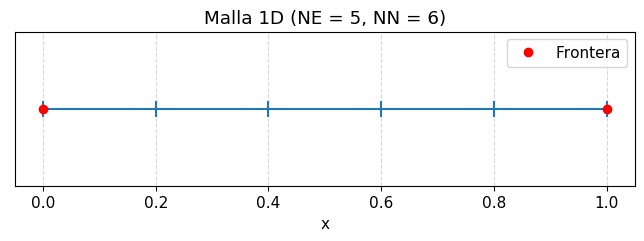

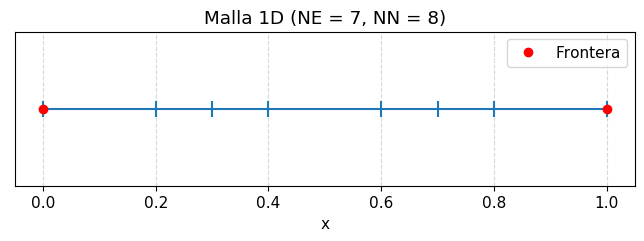

In [94]:
# Crear malla uniforme inicial en [0, 1] con 5 elementos
mesh1d = Triangulation1d.create_uniform(a=0.0, b=1.0, n_elements=5)
# Graficar la malla refinada
fig, ax = mesh1d.plotTriangulation()
plt.show()
# Refinar únicamente los elementos 1 y 3 (refinamiento adaptativo local)
marked = [1, 3]
mesh1d.refinement(marked)

# Graficar la malla refinada
fig, ax = mesh1d.plotTriangulation()
plt.show()

In [95]:
import numpy as np
import scipy.sparse as sps
import scipy.sparse.linalg as sps_linalg
from scipy.special import roots_jacobi

def myfirstfem1d(problem, mesh):
    """
    1D FEM Solver para el problema elíptico con asignación geográfica 
    robusta de condiciones de frontera de Dirichlet.
    """
    NN = mesh.NN
    NE = mesh.NE
    
    # Cuadratura de Gauss-Legendre (2 puntos)
    x, w = roots_jacobi(n=2, alpha=0, beta=0)
    phi = np.array([(1.0 - x) / 2.0, (1.0 + x) / 2.0])  # (2, n_quad)
    dphi_dref = np.array([-0.5, 0.5])                   # (2,)
    
    rows_list, cols_list, vals_list = [], [], []
    b = np.zeros(NN, dtype=np.float64)

    for j in range(NE):
        dofK = mesh.Elements[j, :]
        K = mesh.Coordinates[dofK]
        hi = K[1] - K[0]
        
        # Mapeo al intervalo de referencia [-1, 1]
        y = K[0] + 0.5 * hi * (x + 1.0)
        px = problem.p(y)
        qx = problem.q(y)
        rx = problem.r(y)
        fx = problem.f(y)
        
        # 1. Matriz de Rigidez Local (Stiffness): integral(p * phi_j' * phi_i')
        grad_outer = np.outer(dphi_dref, dphi_dref)
        SK = (2.0 / hi) * np.sum(w * px) * grad_outer
        
        # 2. Matriz de Convección Local (Convection): integral(q * phi_j' * phi_i)
        q_weighted_i = np.sum(w * qx * phi, axis=1)
        BK = np.outer(q_weighted_i, dphi_dref)
        
        # 3. Matriz de Masa Local (Mass): integral(r * phi_j * phi_i)
        phi_outer = np.einsum('iQ, jQ -> ijQ', phi, phi)
        MK = (hi / 2.0) * np.sum(w * rx * phi_outer, axis=-1)
        
        AK = SK + BK + MK
        bK = (hi / 2.0) * np.sum(w * fx * phi, axis=1)
        
        b[dofK] += bK
        r_grid, c_grid = np.meshgrid(dofK, dofK, indexing='ij')
        rows_list.extend(r_grid.ravel())
        cols_list.extend(c_grid.ravel())
        vals_list.extend(AK.ravel())

    # Construcción de la matriz global dispersa
    A = sps.coo_matrix((vals_list, (rows_list, cols_list)), shape=(NN, NN), dtype=np.float64).tocsc()
    uh = np.zeros(NN, dtype=np.float64)
    
    # ==========================================================================
    # ASIGNACIÓN GEOMÉTRICA ROBUSTA DE NODOS DE FRONTERA
    # ==========================================================================
    boundary_coords = mesh.Coordinates[mesh.Boundary]
    
    # Identificar el índice del nodo en el extremo izquierdo (x_min) y derecho (x_max)
    left_boundary_node = mesh.Boundary[np.argmin(boundary_coords)]
    right_boundary_node = mesh.Boundary[np.argmax(boundary_coords)]
    
    # Asignar valores de Dirichlet correctamente según la posición espacial
    uh[left_boundary_node] = problem.A
    uh[right_boundary_node] = problem.B
    
    # Corrección del vector de carga global por Dirichlet no homogéneo
    b = b - A.dot(uh)
    
    # Nodos libres (excluyendo únicamente los dos nodos de frontera)
    dirichlet_nodes = np.array([left_boundary_node, right_boundary_node])
    free_nodes = np.setdiff1d(np.arange(NN), dirichlet_nodes)
    
    # Rebanado 2D correcto para matrices dispersas CSC
    AFree = A[free_nodes, :][:, free_nodes]
    uh[free_nodes] = sps_linalg.spsolve(AFree, b[free_nodes])
    
    return uh

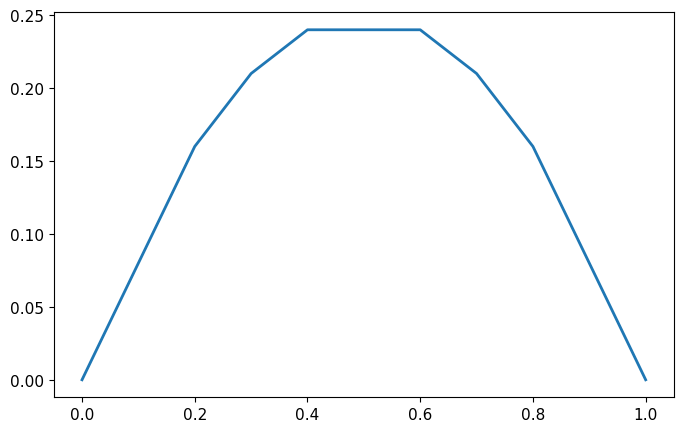

In [96]:
uh = myfirstfem1d(problema1, mesh1d)
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(mesh1d.Coordinates, uh)
# fig = mesh1d.plotTriangulation(fig)
plt.show()

## Problema: solucion lineal $u(x) = 1-x$

Error Máximo Nodal ||u - u_h||_inf: 4.4409e-16


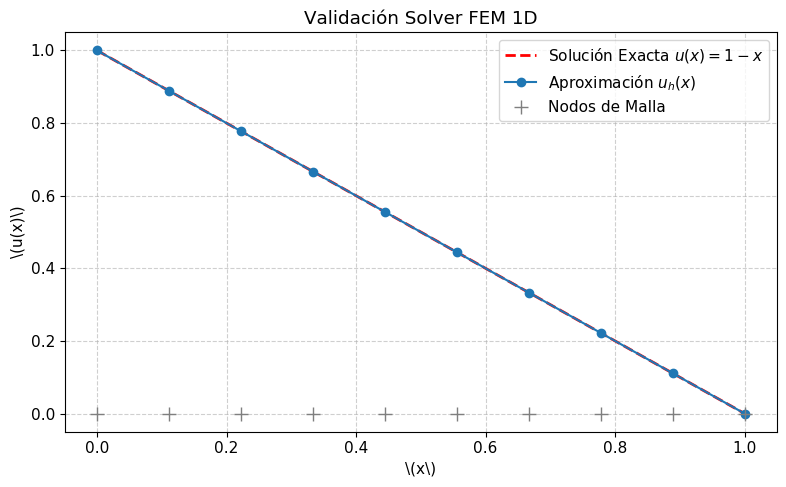

In [97]:
a = 0.0; b = 1.0
f = lambda x: 4.0 * (-1.0) + 5.0 * (1.0 - x)
A = 1.0; B = 0.0
p = lambda x: 1.0 + 0 * x
q = lambda x: 4.0 + 0 * x
r = lambda x: 5.0 + 0 * x
uexact = lambda x: 1.0 - x

problema = problem1delliptic(a, b, f, A, B, p, q, r,dp=0.0, uexact=uexact)

npoints = 10
Coordinates = np.linspace(a, b, npoints, endpoint=True)
Elements1d = np.column_stack([np.arange(npoints - 1), np.arange(1, npoints)])
mesh = Triangulation1d(Coordinates, Elements1d, Boundary=[0, npoints - 1])

# Resolver
uh = myfirstfem1d(problema, mesh)

# Error máximo nodal
err_max = np.max(np.abs(uh - uexact(mesh.Coordinates)))
print(f"Error Máximo Nodal ||u - u_h||_inf: {err_max:.4e}")

# Gráfica
fig, ax = plt.subplots(figsize=(8, 5))
x_fine = np.linspace(a, b, 200)

ax.plot(x_fine, uexact(x_fine), 'r--', label='Solución Exacta $u(x) = 1-x$', linewidth=2)
ax.plot(mesh.Coordinates, uh, 'o-', color='C0', label='Aproximación $u_h(x)$', markersize=6, linewidth=1.5)
ax.plot(mesh.Coordinates, np.zeros(mesh.NN), '+', color='C7', label='Nodos de Malla', markersize=10)

ax.set_xlabel('\(x\)')
ax.set_ylabel('\(u(x)\)')
ax.set_title('Validación Solver FEM 1D')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## Adaptive Mesh Refinement - A posteriori error estimation

### Primero tenemos el refinamiento de la malla, marcando intervalos y refinandolos por la mitad

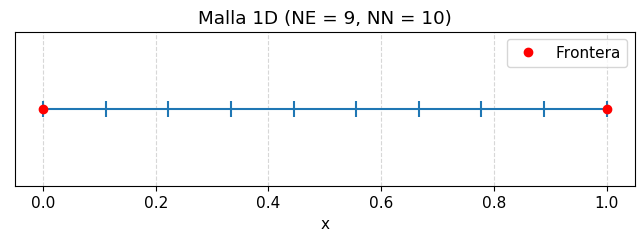

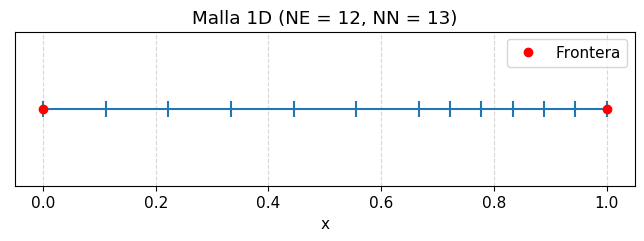

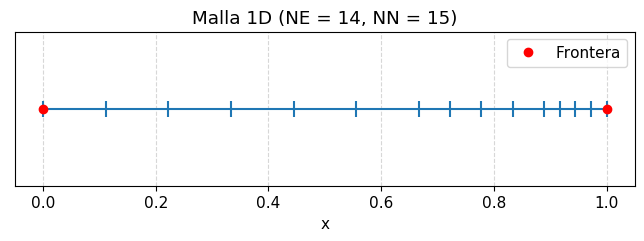

In [98]:
# Triangulacion uniforme
npoints = 10
z = np.linspace(0,1,npoints,endpoint=True)
Coordinates = z
Elements1d = np.asarray([[i, i+1] for i in range(npoints-1)])
mesh = Triangulation1d(Coordinates, Elements1d, Boundary=[0,npoints-1])
fig = mesh.plotTriangulation()
markedTri = [6,7,8]
mesh.refinement(markedTri)
fig = mesh.plotTriangulation()
markedTri = [10,11]
mesh.refinement(markedTri)
fig = mesh.plotTriangulation()

In [99]:

import numpy as np
from scipy.special import roots_jacobi

def compute_apostestimator(mesh, uh, problem, TOL=1e-2, marking_strategy='dorfler', theta=0.5):
    """
    Calcula el estimador de error a posteriori basado en residuos para FEM 1D (P1)
    y aplica refinamiento adaptativo de malla (AMR).
    
    Parámetros:
    mesh : Triangulation1d
    Objeto de la malla 1D.
    uh : ndarray
    Solución de elementos finitos P1.
    problem : Problem1DElliptic
    Instancia con coeficientes f, p, dp, q, r, K0.
    TOL : float
    Tolerancia global deseada para el estimador de error.
    marking_strategy : str ('dorfler' o 'threshold')
    Criterio de marcado para selección de elementos a refinar.
    theta : float
    Parámetro de marcado de Dörfler (0 < theta <= 1).
    
    Retorna:
    
    ---
    
    ```
    converged : bool
        True si la tolerancia global se satisface.
    mesh : Triangulation1d
        Malla (refinada si converged es False).
    eta_total : float
        Estimador global de error (norma L2 del residuo ponderado).
    """
    K0 = getattr(problem, 'K0', 1.0)
    if K0 is None:
        K0 = 1.0
    
    # Puntos y pesos de cuadratura de Gauss (4 puntos)
    x_quad, w_quad = roots_jacobi(n=4, alpha=0, beta=0)
    
    eta_K_sq = np.zeros(mesh.NE, dtype=np.float64)
    
    for j in range(mesh.NE):
        dofK = mesh.Elements[j, :]
        uK = uh[dofK]
        K = mesh.Coordinates[dofK]
        hK = K[1] - K[0]
        
        # Derivada espacial du_h/dx en K (constante en P1)
        duh = (uK[1] - uK[0]) / hK
        
        # Mapeo afín al intervalo de referencia [-1, 1]
        y_quad = K[0] + 0.5 * hK * (x_quad + 1.0)
        
        # Evaluar u_h en los puntos de cuadratura
        uh_quad = uK[0] * (K[1] - y_quad) / hK + uK[1] * (y_quad - K[0]) / hK
        
        # Evaluaciones de coeficientes
        fx = problem.f(y_quad)
        dpx = problem.dp(y_quad)
        qx = problem.q(y_quad)
        rx = problem.r(y_quad)
        
        # Residuo fuerte elemental: R(u_h) = f - (-d/dx(p du_h/dx) + q du_h/dx + r u_h)
        # Nota: -d/dx(p du_h/dx) = -dp/dx * du_h/dx - p * d^2u_h/dx^2 (d^2u_h/dx^2 = 0 en P1)
        residual = fx - (-dpx * duh + qx * duh + rx * uh_quad)
        
        # Integración del residuo ||R(u_h)||^2_L2(K)
        norm_R_sq = (hK / 2.0) * np.sum(w_quad * (residual ** 2))
        
        # Estimador local ponderado: eta_K^2 = hK^2 * ||R(u_h)||^2_L2(K)
        eta_K_sq[j] = (hK ** 2) * norm_R_sq
    
    # Estimador global de error: eta_total = sqrt( sum_K eta_K^2 )
    eta_total = np.sqrt(np.sum(eta_K_sq))
    target_tol = TOL / K0
    
    print(f"[AMR] Error Estimado = {eta_total:.6e} | Tolerancia = {target_tol:.6e}")
    
    if eta_total <= target_tol:
        print(" -> Tolerancia alcanzada. No se requiere refinamiento.")
        return True, mesh, eta_total
    
    # ==========================================================================
    # ESTRATEGIA DE MARCADO (MARKING STRATEGY)
    # ==========================================================================
    marked_elements = []
    
    if marking_strategy == 'dorfler':
        # Marcado de Dörfler: Selecciona el conjunto mínimo M tal que sum_{K in M} eta_K^2 >= theta * eta_total^2
        sorted_indices = np.argsort(eta_K_sq)[::-1]
        cumsum_eta = np.cumsum(eta_K_sq[sorted_indices])
        cutoff = theta * (eta_total ** 2)
        
        n_marked = np.searchsorted(cumsum_eta, cutoff) + 1
        marked_elements = sorted_indices[:n_marked].tolist()
        
    elif marking_strategy == 'threshold':
        # Marcado por umbral relativo
        max_eta_sq = np.max(eta_K_sq)
        marked_elements = np.where(eta_K_sq >= theta * max_eta_sq)[0].tolist()
        
    else:
        # Umbral absoluto por elemento
        num_tol_sq = (target_tol ** 2) / mesh.NE
        marked_elements = np.where(eta_K_sq > num_tol_sq)[0].tolist()
    
    print(f" -> Marcados {len(marked_elements)} / {mesh.NE} elementos para refinamiento.")
    mesh.refinement(marked_elements)
    
    return False, mesh, eta_total

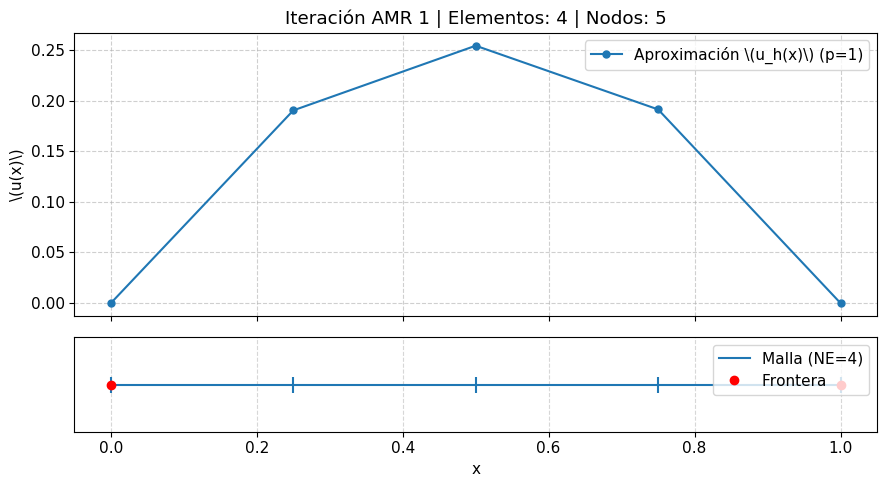

[AMR] Error Estimado = 5.148210e-01 | Tolerancia = 1.000000e-03
 -> Marcados 2 / 4 elementos para refinamiento.


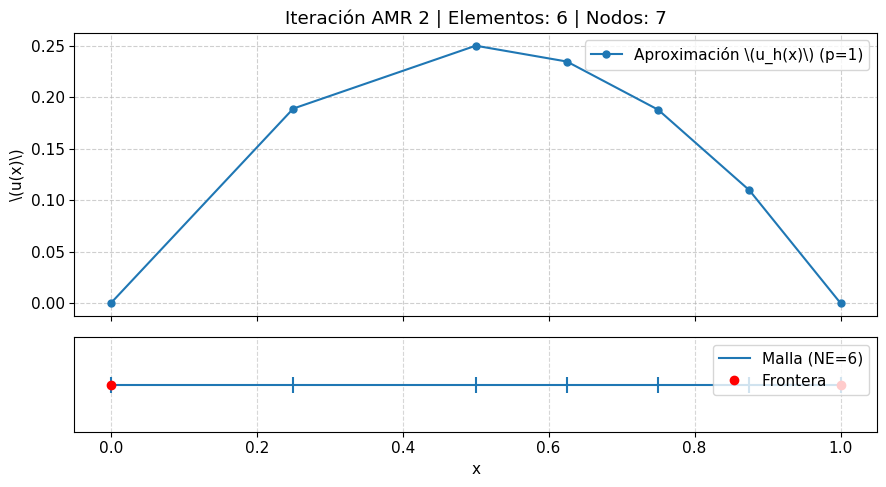

[AMR] Error Estimado = 4.067863e-01 | Tolerancia = 1.000000e-03
 -> Marcados 2 / 6 elementos para refinamiento.


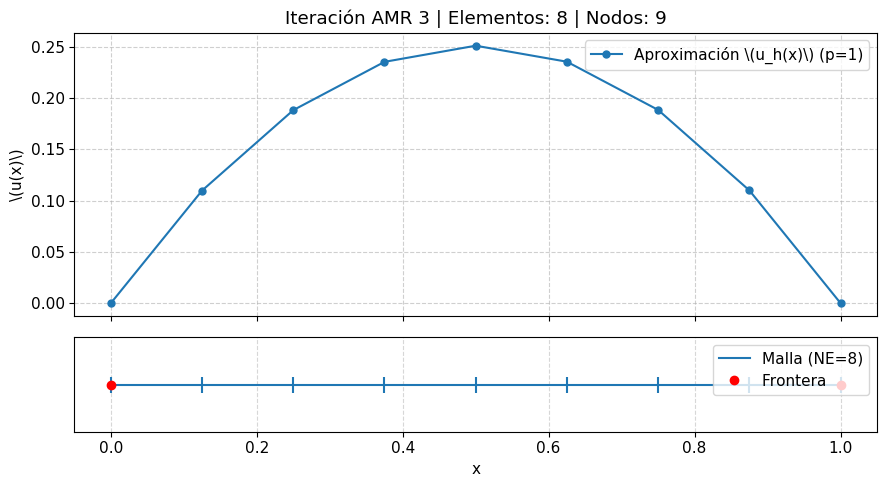

[AMR] Error Estimado = 2.518444e-01 | Tolerancia = 1.000000e-03
 -> Marcados 4 / 8 elementos para refinamiento.


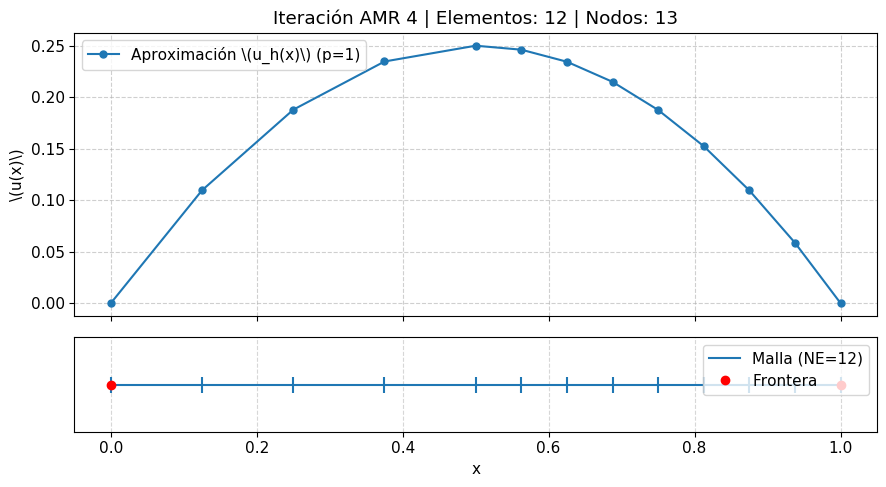

[AMR] Error Estimado = 1.990672e-01 | Tolerancia = 1.000000e-03
 -> Marcados 3 / 12 elementos para refinamiento.


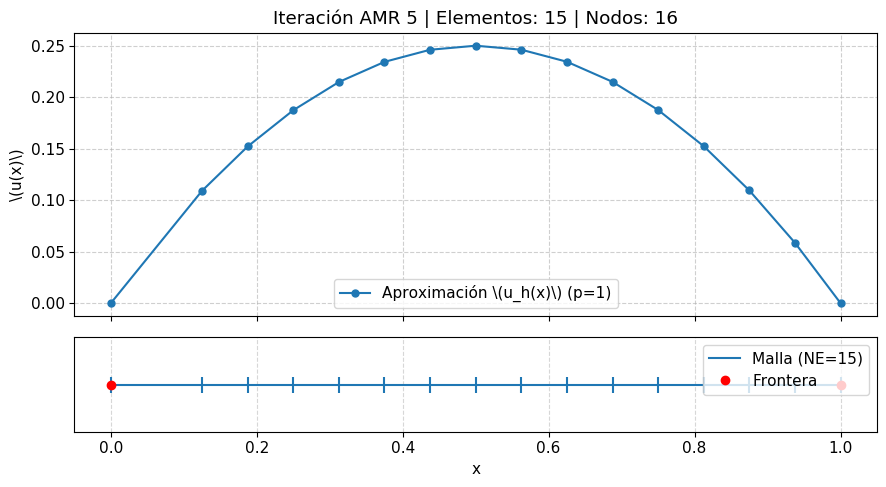

[AMR] Error Estimado = 1.473449e-01 | Tolerancia = 1.000000e-03
 -> Marcados 4 / 15 elementos para refinamiento.


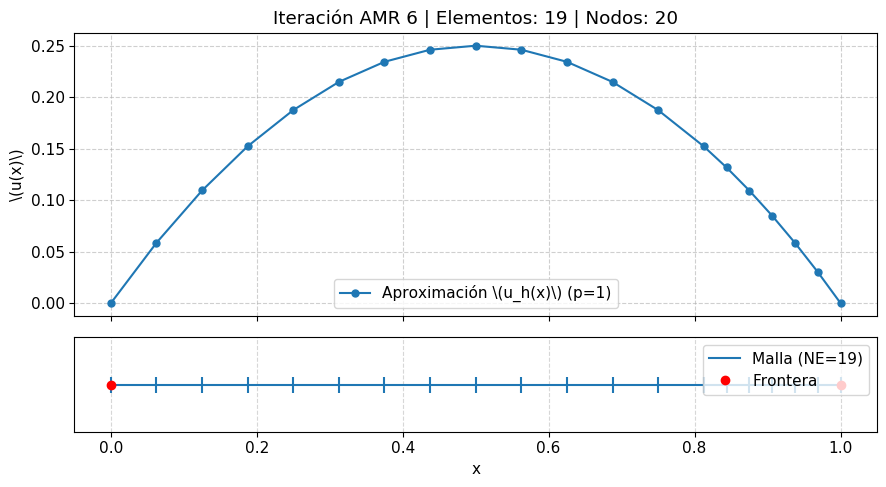

[AMR] Error Estimado = 1.160862e-01 | Tolerancia = 1.000000e-03
 -> Marcados 7 / 19 elementos para refinamiento.


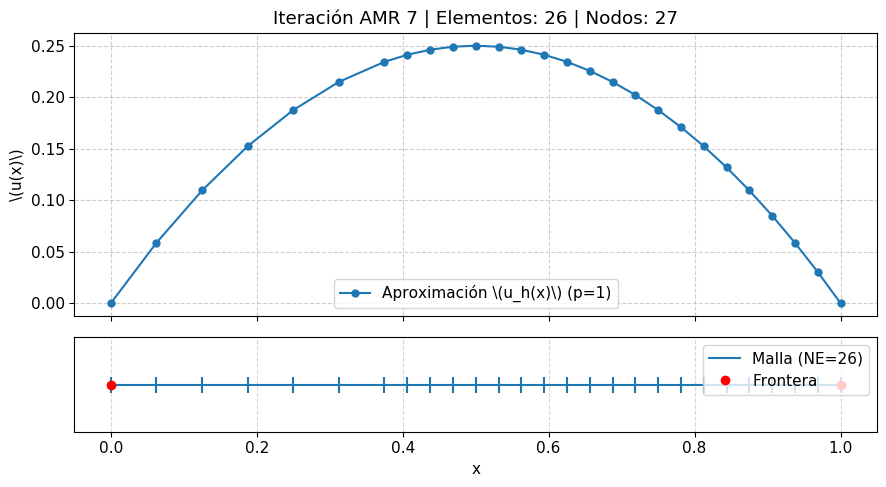

[AMR] Error Estimado = 9.126918e-02 | Tolerancia = 1.000000e-03
 -> Marcados 5 / 26 elementos para refinamiento.


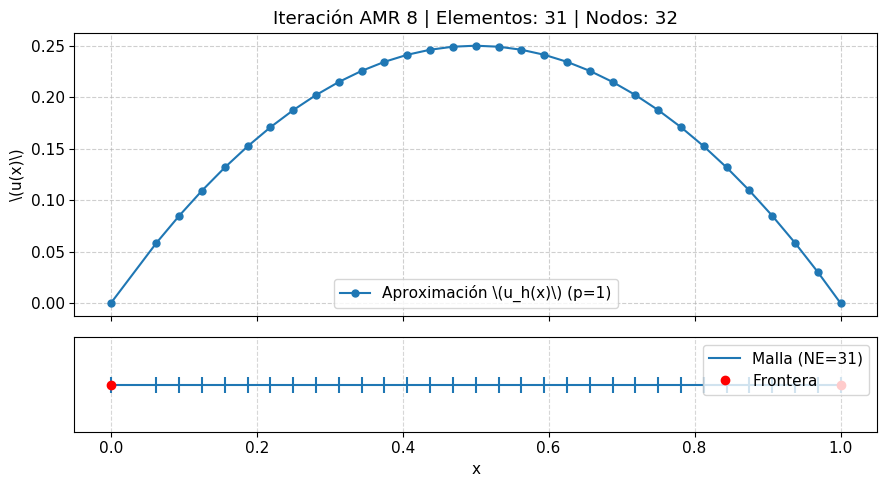

[AMR] Error Estimado = 6.817475e-02 | Tolerancia = 1.000000e-03
 -> Marcados 12 / 31 elementos para refinamiento.


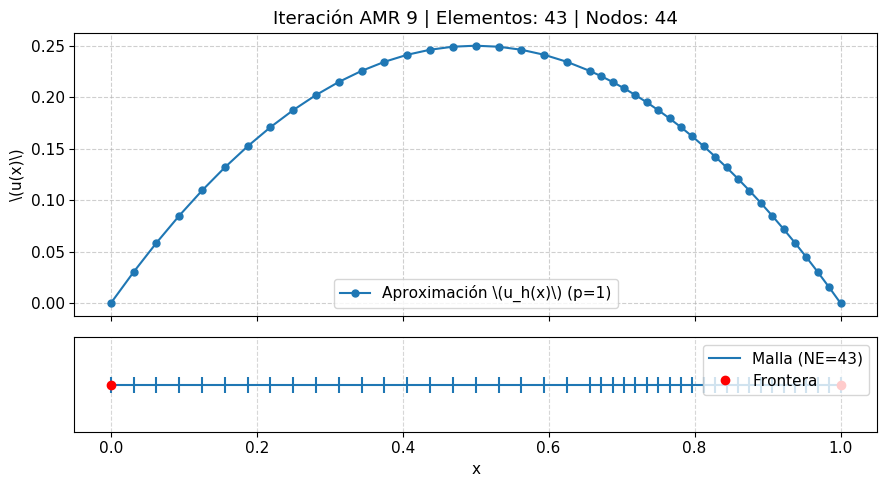

[AMR] Error Estimado = 5.386813e-02 | Tolerancia = 1.000000e-03
 -> Marcados 12 / 43 elementos para refinamiento.


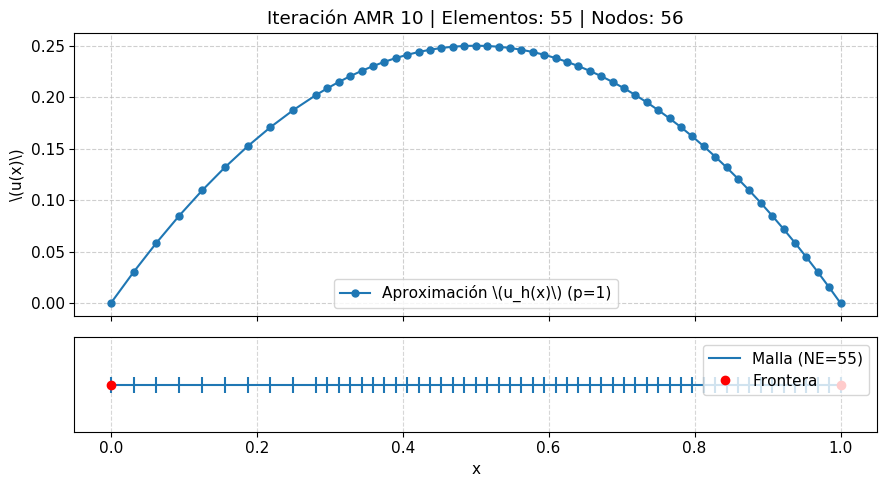

[AMR] Error Estimado = 4.245056e-02 | Tolerancia = 1.000000e-03
 -> Marcados 8 / 55 elementos para refinamiento.


In [100]:
## New problem
a = 0.0; b= 1.0
f = lambda x: 2.0 + 2.0*(-2*x+1) + 5.0 * x * (1-x)
A = .0; B = .0
p = lambda x: 1.0+0*x
r = lambda x: 5.0+0*x
dp = lambda x: 0*x
q = lambda x: 2.0+.0*x
uexact = lambda x: x*(1-x)

problema = problem1delliptic(a,b,f,A,B,p,q,r,dp,uexact)
TOL = 1e-3
max_iterations = 10
theta = 0.5  # Parámetro de marcado de Dörfler

# Malla inicial uniforme (ejemplo con 4 elementos)
npoints_init = 5
Coordinates = np.linspace(problema.a, problema.b, npoints_init, endpoint=True)
Elements1d = np.column_stack([np.arange(npoints_init - 1), np.arange(1, npoints_init)])
mesh = Triangulation1d(Coordinates, Elements1d)

for it in range(max_iterations):
    # 1. RESOLVER el problema primal en la malla actual
    uh = myfirstfem1d(problema, mesh)
    
    # Malla ordenada para visualización limpia
    mesh.sort_mesh()
    
    # 2. GRAFICAR la solución actual y la estructura de la malla
    fig, (ax_sol, ax_mesh) = plt.subplots(
        2, 1, figsize=(9, 5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True
    )
    
    # --- Subgráfico Superior: Solución Aproximada vs Exacta ---
    if hasattr(problema, 'u_exact') and problema.u_exact is not None:
        x_fine = np.linspace(problema.a, problema.b, 300)
        ax_sol.plot(x_fine, problema.u_exact(x_fine), 'r--', label='Solución Exacta \(u(x)\)', linewidth=1.8)
        
    ax_sol.plot(mesh.Coordinates, uh, 'o-', color='C0', label=f'Aproximación \(u_h(x)\) (p=1)', markersize=5, linewidth=1.5)
    ax_sol.set_ylabel('\(u(x)\)')
    ax_sol.set_title(f'Iteración AMR {it + 1} | Elementos: {mesh.NE} | Nodos: {mesh.NN}')
    ax_sol.grid(True, linestyle='--', alpha=0.6)
    ax_sol.legend(loc='best')
    
    # --- Subgráfico Inferior: Malla y Nodos Refinados ---
    mesh.plotTriangulation(ax=ax_mesh, color='C0', show_nodes=True, label=f'Malla (NE={mesh.NE})')
    ax_mesh.set_title('')  # Limpiar título secundario
    
    plt.tight_layout()
    plt.show()
    
    # 3. ESTIMAR el error y REFINAR si la tolerancia no se satisface
    converged, mesh, eta = compute_apostestimator(
        mesh, uh, problema, TOL=TOL, marking_strategy='dorfler', theta=theta
    )
    
    if converged:
        print(f"\nProceso AMR convergido exitosamente en la iteración {it + 1}.")
        break

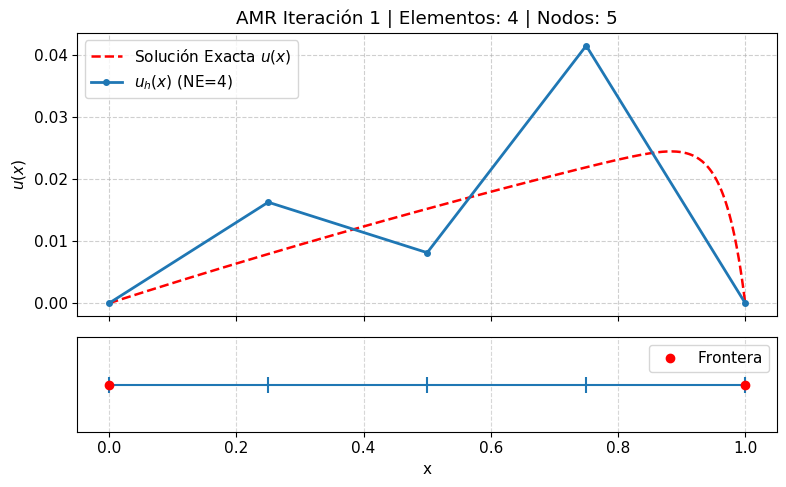

[AMR] Error Estimado = 8.696841e-01 | Tolerancia = 4.224879e-03
 -> Marcados 1 / 4 elementos para refinamiento.


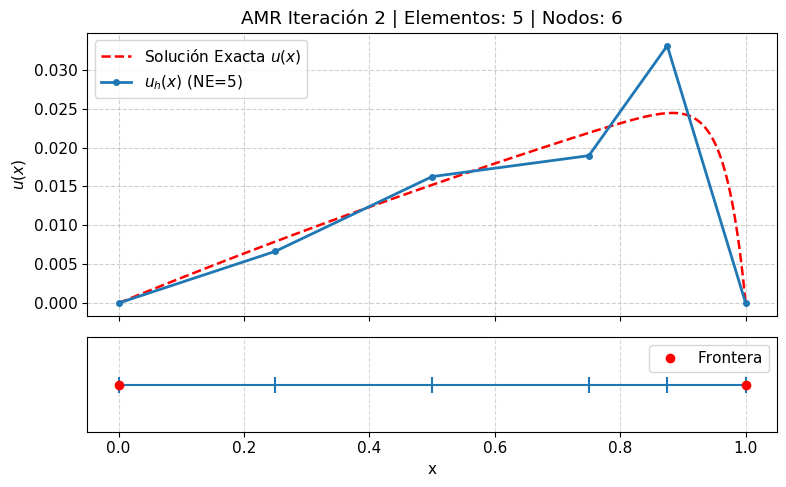

[AMR] Error Estimado = 4.119770e-01 | Tolerancia = 4.224879e-03
 -> Marcados 1 / 5 elementos para refinamiento.


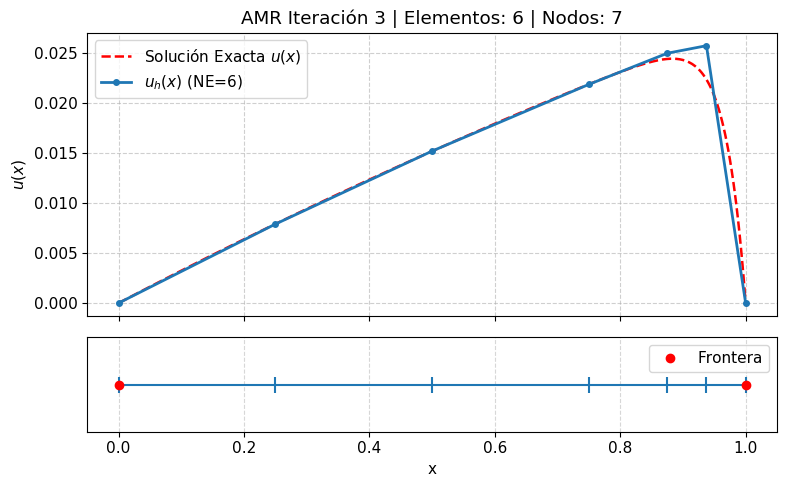

[AMR] Error Estimado = 2.069092e-01 | Tolerancia = 4.224879e-03
 -> Marcados 1 / 6 elementos para refinamiento.


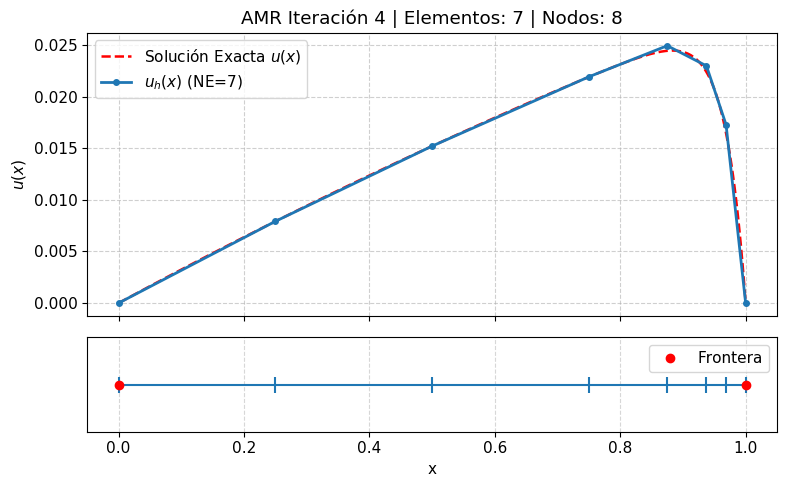

[AMR] Error Estimado = 1.061997e-01 | Tolerancia = 4.224879e-03
 -> Marcados 1 / 7 elementos para refinamiento.


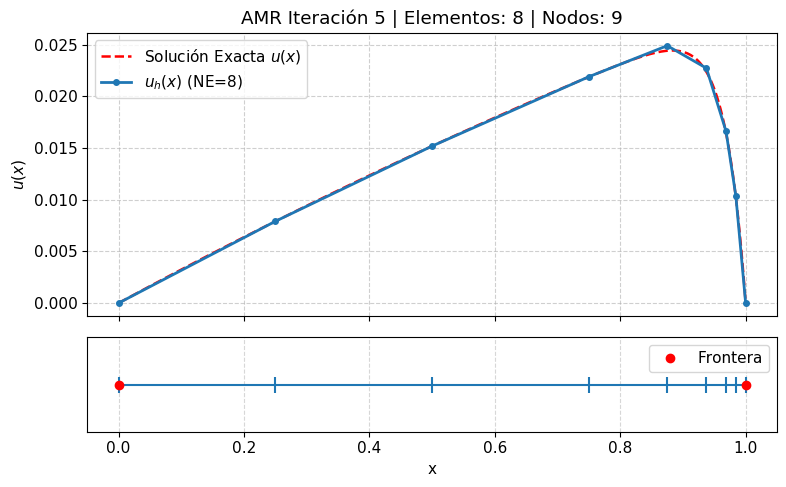

[AMR] Error Estimado = 6.690812e-02 | Tolerancia = 4.224879e-03
 -> Marcados 2 / 8 elementos para refinamiento.


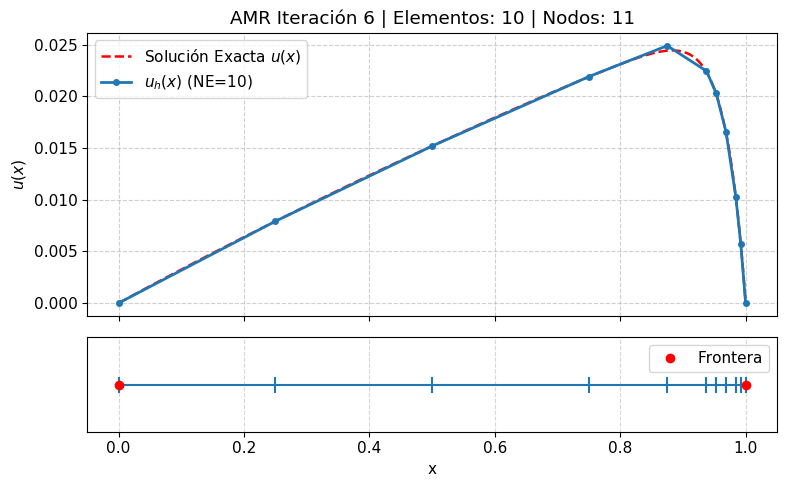

[AMR] Error Estimado = 4.834492e-02 | Tolerancia = 4.224879e-03
 -> Marcados 2 / 10 elementos para refinamiento.


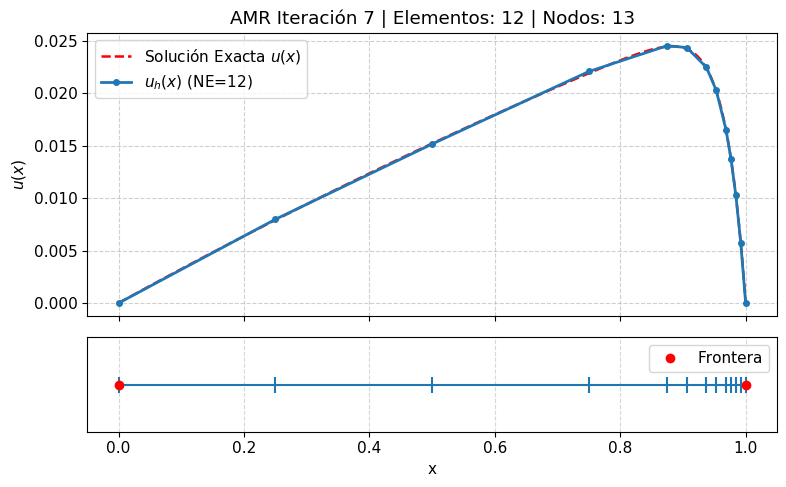

[AMR] Error Estimado = 3.519730e-02 | Tolerancia = 4.224879e-03
 -> Marcados 3 / 12 elementos para refinamiento.


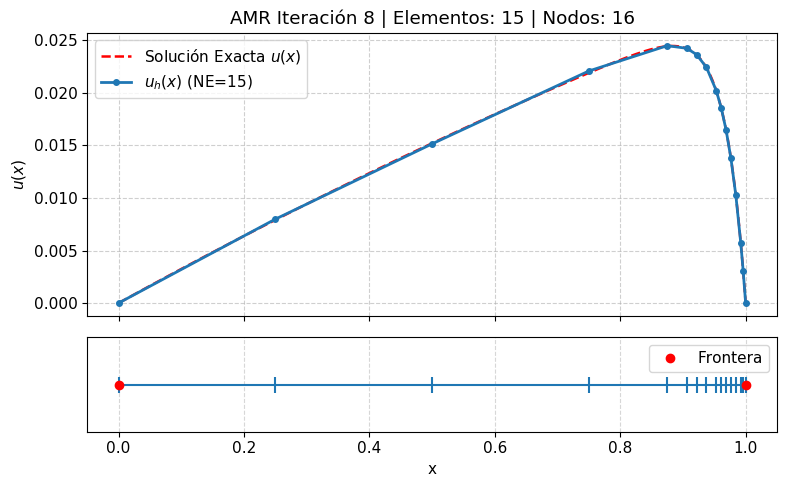

[AMR] Error Estimado = 2.694802e-02 | Tolerancia = 4.224879e-03
 -> Marcados 4 / 15 elementos para refinamiento.


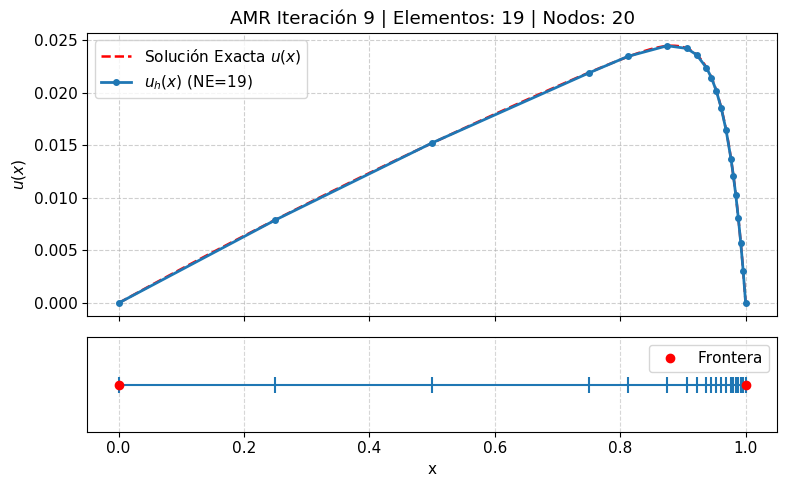

[AMR] Error Estimado = 2.008584e-02 | Tolerancia = 4.224879e-03
 -> Marcados 5 / 19 elementos para refinamiento.


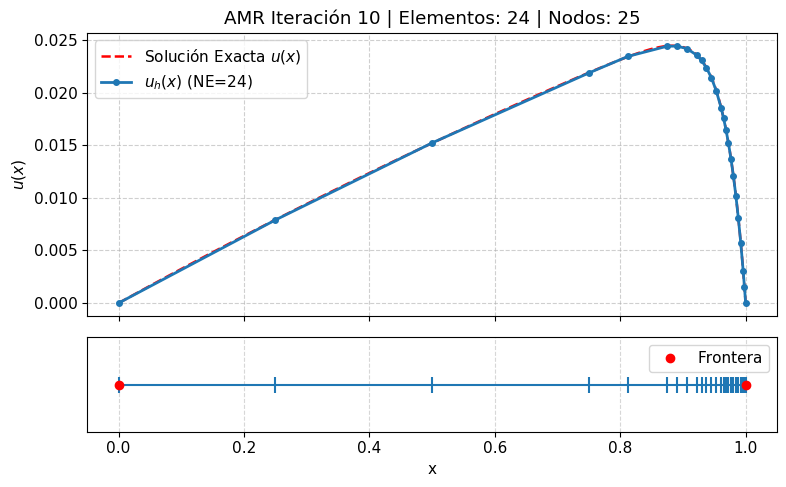

[AMR] Error Estimado = 1.596277e-02 | Tolerancia = 4.224879e-03
 -> Marcados 7 / 24 elementos para refinamiento.


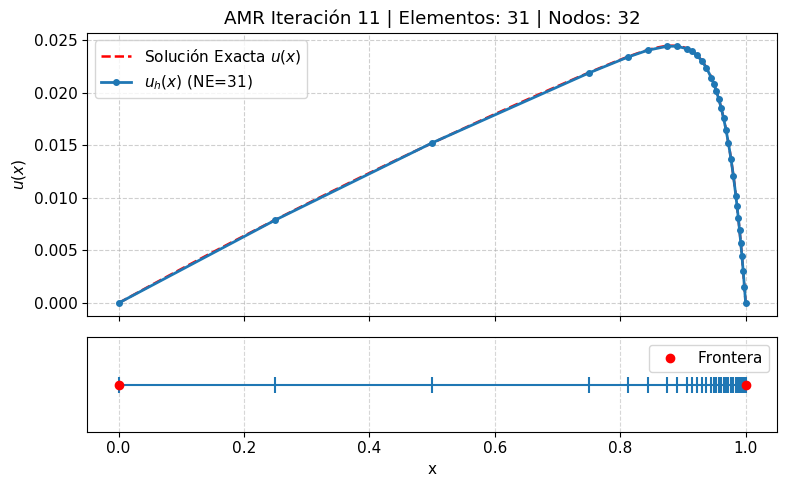

[AMR] Error Estimado = 1.221660e-02 | Tolerancia = 4.224879e-03
 -> Marcados 8 / 31 elementos para refinamiento.


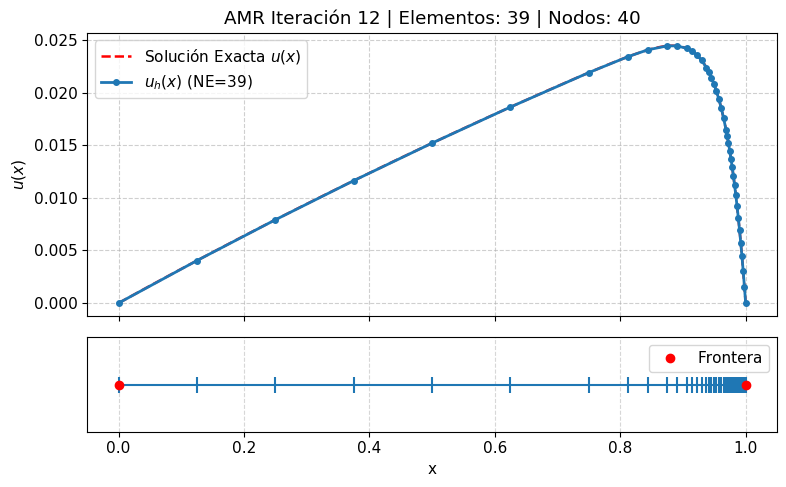

[AMR] Error Estimado = 9.293596e-03 | Tolerancia = 4.224879e-03
 -> Marcados 10 / 39 elementos para refinamiento.


In [104]:
## New problem
a = 0.0; b= 1.0
f = lambda x: 1.0 +0*x
A = .0; B = .0
p = lambda x: 1.0+0*x
r = lambda x: 10.0+0*x
dp = lambda x: 0*x
q = lambda x: 30+0*x
K0 = (1.0+np.sqrt(500.0))/np.pi**2

# Construcción de la solución exacta analítica
m1 = 15.0 + np.sqrt(235.0)
m2 = 15.0 - np.sqrt(235.0)

M = np.array([[1.0, 1.0], 
              [np.exp(m1), np.exp(m2)]])
rhs = np.array([-0.1, -0.1])
C1, C2 = np.linalg.solve(M, rhs)

uexact = lambda x: C1 * np.exp(m1 * x) + C2 * np.exp(m2 * x) + 0.1
problema = problem1delliptic(a,b,f,A,B,p,q,r,dp,K0=K0)
npoints_init = 5
Coordinates = np.linspace(a, b, npoints_init, endpoint=True)
Elements1d = np.column_stack([np.arange(npoints_init - 1), np.arange(1, npoints_init)])
mesh = Triangulation1d(Coordinates, Elements1d)

TOL = 1e-2
max_iterations = 12

for it in range(max_iterations):
    # Resolver
    uh = myfirstfem1d(problema, mesh)
    
    # Visualizar
    fig, (ax_sol, ax_mesh) = plt.subplots(
        2, 1, figsize=(8, 5), gridspec_kw={'height_ratios': [3, 1]}, sharex=True
    )
    
    x_fine = np.linspace(a, b, 400)
    ax_sol.plot(x_fine, uexact(x_fine), 'r--', label='Solución Exacta $u(x)$', linewidth=1.8)
    ax_sol.plot(mesh.Coordinates, uh, 'o-', color='C0', label=f'$u_h(x)$ (NE={mesh.NE})', markersize=4)
    ax_sol.set_ylabel('$u(x)$')
    ax_sol.set_title(f'AMR Iteración {it + 1} | Elementos: {mesh.NE} | Nodos: {mesh.NN}')
    ax_sol.grid(True, linestyle='--', alpha=0.6)
    ax_sol.legend(loc='best')
    
    mesh.plotTriangulation(ax=ax_mesh, color='C0', show_nodes=True)
    ax_mesh.set_title('')
    plt.tight_layout()
    plt.show()
    
    # Estimar y Refinar
    converged, mesh, eta = compute_apostestimator(
        mesh, uh, problema, TOL=TOL, theta=0.5
    )
    
    if converged:
        print(f"\n[ÉXITO] Algoritmo AMR convergido en la iteración {it + 1}.")
        break